**Stage 1: SETUP**

2025-12-01 04:42:31.766561: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764564151.982471      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764564152.044605      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Num GPUs Available: 2
GPU memory growth enabled.
DATA_ROOT set to: /kaggle/input/sickle-cell-disease-dataset
positive_labelled: FOUND -> /kaggle/input/sickle-cell-disease-dataset/Positive/Labelled | images: 422
positive_unlabelled: FOUND -> /kaggle/input/sickle-cell-disease-dataset/Positive/Unlabelled | images: 422
negative_clear: FOUND -> /kaggle/input/sickle-cell-disease-dataset/Negative/Clear | images: 147


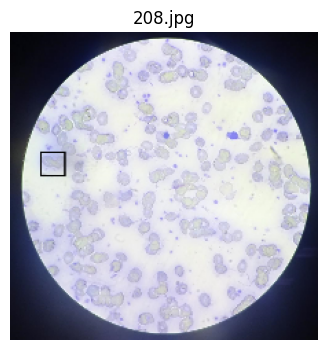

In [1]:
import os
from pathlib import Path
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

# optional import
try:
    import xgboost as xgb
except Exception:
    print("xgboost not found. If you need it, run: !pip install xgboost")
    xgb = None

# reproducibility
RSEED = 42
random.seed(RSEED)
np.random.seed(RSEED)
tf.random.set_seed(RSEED)

# GPU (Kaggle-friendly)
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
if gpus:
    try:
        # Attempt to set memory growth (safe for TF2)
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print("GPU memory growth enabled.")
    except Exception as e:
        print("Could not enable memory growth:", e)

# Dataset path detection
# If dataset input slug differs, set EXPECTED_SLUG manually.
EXPECTED_SLUG = "sickle-cell-disease-dataset" 
kaggle_input_root = Path("/kaggle/input")
DATA_ROOT = None

# Try to auto-detect
if (kaggle_input_root / EXPECTED_SLUG).exists():
    DATA_ROOT = kaggle_input_root / EXPECTED_SLUG
else:
    # fallback: if there is only one dataset, use that
    datasets = [p for p in kaggle_input_root.iterdir() if p.is_dir()]
    if len(datasets) == 1:
        DATA_ROOT = datasets[0]
    else:
        # trying to find a folder containing 'Positive' and 'Negative' subfolders
        for p in datasets:
            if (p / "Positive").exists() and (p / "Negative").exists():
                DATA_ROOT = p
                break

if DATA_ROOT is None:
    print("Could not auto-detect dataset folder under /kaggle/input.")
    print("Please add your dataset in the Notebook 'Input' panel and/or set EXPECTED_SLUG accordingly.")
else:
    print("DATA_ROOT set to:", DATA_ROOT)

# Define dataset subfolders (adjust if your structure differs)
IMG_SIZE = 224
positive_labelled_dir   = DATA_ROOT / "Positive" / "Labelled"
positive_unlabelled_dir = DATA_ROOT / "Positive" / "Unlabelled"
negative_img_dir        = DATA_ROOT / "Negative" / "Clear"

# helper: count images
def count_images(p: Path, exts=(".png",".jpg",".jpeg",".tif",".tiff")):
    if p is None or not p.exists():
        return None
    return sum(1 for f in p.rglob("*") if f.suffix.lower() in exts)

paths = {
    "positive_labelled": positive_labelled_dir,
    "positive_unlabelled": positive_unlabelled_dir,
    "negative_clear": negative_img_dir
}

for name, p in paths.items():
    c = count_images(p)
    if c is None:
        print(f"{name}: NOT FOUND -> {p}")
    else:
        print(f"{name}: FOUND -> {p} | images: {c}")

# quick smoke test: load & display one image from any existing directory
def show_one_example(path: Path):
    if path is None or not path.exists():
        return
    for f in path.rglob("*"):
        if f.suffix.lower() in (".png",".jpg",".jpeg",".tif",".tiff"):
            img = cv2.imread(str(f))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            plt.figure(figsize=(4,4))
            plt.imshow(img)
            plt.title(f.name)
            plt.axis("off")
            plt.show()
            return

# display a sample if available
if DATA_ROOT is not None:
    for p in paths.values():
        if p.exists():
            show_one_example(p)
            break

**Stage 2: PREPROCESSING & DATASET PREPARATION**

Using DATA_ROOT: /kaggle/input/sickle-cell-disease-dataset
Total samples (manifest): 569
label
1    422
0    147
Name: count, dtype: int64
Split sizes -> Train: 312, Val: 86, Test: 171
Saved manifests to: /kaggle/working/train_manifest.csv /kaggle/working/val_manifest.csv /kaggle/working/test_manifest.csv
Class weights: {0: 1.9259259259259258, 1: 0.6753246753246753}


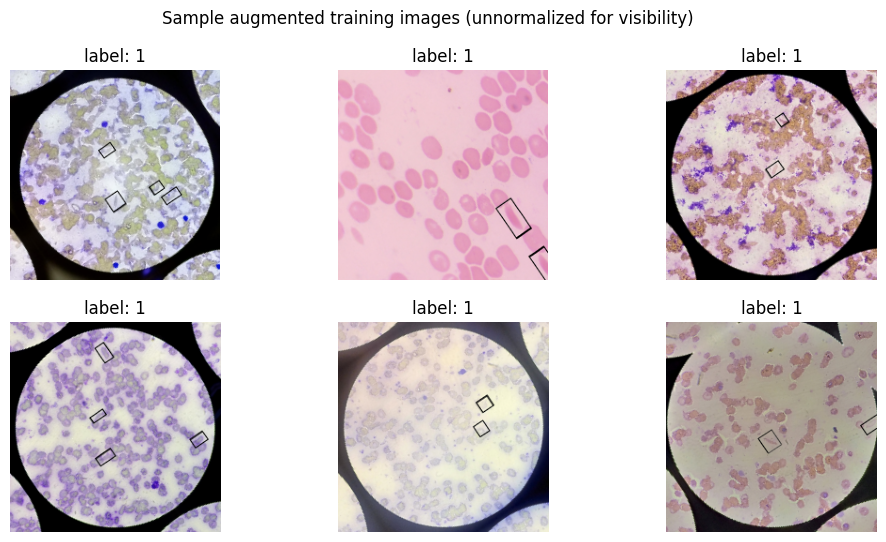

Stage 2 completed. train_ds, val_ds, test_ds and manifests are ready.
Manifests are saved at: /kaggle/working/train_manifest.csv /kaggle/working/val_manifest.csv /kaggle/working/test_manifest.csv


In [9]:
# Builds manifests, creates tf.data pipelines, applies Keras augmentations (no tensorflow-addons),
# performs stratified splits, computes class weights, and shows a smoke-test batch.

import os
from pathlib import Path
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Config / dataset detection
EXPECTED_SLUG = "sickle-cell-disease-dataset"  # change if your dataset slug differs
KAGGLE_INPUT = Path("/kaggle/input")
OUT_DIR = Path("/kaggle/working")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Use DATA_ROOT if set previously (Stage 1). Otherwise auto-detect under /kaggle/input
try:
    DATA_ROOT  # noqa: F821
except NameError:
    DATA_ROOT = None

if DATA_ROOT is None:
    candidate = KAGGLE_INPUT / EXPECTED_SLUG
    if candidate.exists():
        DATA_ROOT = candidate
    else:
        datasets = [p for p in KAGGLE_INPUT.iterdir() if p.is_dir()]
        if len(datasets) == 1:
            DATA_ROOT = datasets[0]
        else:
            found = None
            for p in datasets:
                if (p / "Positive").exists() and (p / "Negative").exists():
                    found = p
                    break
            if found is not None:
                DATA_ROOT = found

if DATA_ROOT is None:
    raise RuntimeError("Could not auto-detect dataset under /kaggle/input. Set EXPECTED_SLUG or define DATA_ROOT manually.")
print("Using DATA_ROOT:", DATA_ROOT)

# Subfolder config (update if your structure differs)
POS_LABELLED = DATA_ROOT / "Positive" / "Labelled"
NEG_CLEAR    = DATA_ROOT / "Negative" / "Clear"

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
RSEED = 42
TEST_SIZE = 0.30   # fraction of full dataset used for test
VAL_SIZE = 0.15    # fraction of full dataset used for validation (computed from remaining)

# Kaggle-safe augmentation (Keras layers + rot90 fallback)
# No tensorflow_addons import — to avoids compatibility warnings.
from tensorflow.keras import layers as klayers

aug_model = tf.keras.Sequential([
    klayers.RandomFlip(mode="horizontal_and_vertical"),
    klayers.RandomRotation(factor=0.1),       # approx +/-18 degrees
    klayers.RandomContrast(factor=0.08),
])

def augment(image, label):
    """Apply augmentation using Keras layers; fallback to simple ops if something fails."""
    try:
        # aug_model expects float images in [0,1]
        image = aug_model(image, training=True)
    except Exception:
        # safe fallback using tf ops
        image = tf.image.random_flip_left_right(image)
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        image = tf.image.rot90(image, k)
        image = tf.image.random_brightness(image, max_delta=0.08)
        image = tf.image.random_contrast(image, lower=0.95, upper=1.05)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Image decoding, resizing, normalization
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

def decode_and_resize(filename, label):
    img = tf.io.read_file(filename)
    try:
        img = tf.io.decode_jpeg(img, channels=3, try_recover_truncated=True)
    except Exception:
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    label = tf.cast(label, tf.int32)
    return img, label

def normalize_imagenet(image, label):
    image = (image - IMAGENET_MEAN) / IMAGENET_STD
    return image, label

# Build manifest CSV
def build_manifest(pos_dir: Path, neg_dir: Path, out_csv: Path):
    rows = []
    pos_dir = Path(pos_dir)
    neg_dir = Path(neg_dir)
    exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}
    if pos_dir.exists():
        for p in pos_dir.rglob("*"):
            if p.suffix.lower() in exts:
                rows.append((str(p), 1))
    else:
        print("Warning: positive labelled dir not found:", pos_dir)
    if neg_dir.exists():
        for p in neg_dir.rglob("*"):
            if p.suffix.lower() in exts:
                rows.append((str(p), 0))
    else:
        print("Warning: negative clear dir not found:", neg_dir)
    df = pd.DataFrame(rows, columns=["filepath", "label"])
    df.to_csv(out_csv, index=False)
    return df

manifest_csv = OUT_DIR / "manifest.csv"
manifest = build_manifest(POS_LABELLED, NEG_CLEAR, out_csv=manifest_csv)
print("Total samples (manifest):", len(manifest))
print(manifest.label.value_counts())

if len(manifest) == 0:
    raise RuntimeError("No images found in manifest. Verify POS_LABELLED and NEG_CLEAR paths.")

# Stratified splits
train_df, test_df = train_test_split(manifest, test_size=TEST_SIZE, stratify=manifest.label, random_state=RSEED)
val_fraction_of_train = VAL_SIZE / (1.0 - TEST_SIZE)
train_df, val_df = train_test_split(train_df, test_size=val_fraction_of_train, stratify=train_df.label, random_state=RSEED)
print(f"Split sizes -> Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Save CSVs to /kaggle/working for reproducibility
train_csv = OUT_DIR / "train_manifest.csv"
val_csv   = OUT_DIR / "val_manifest.csv"
test_csv  = OUT_DIR / "test_manifest.csv"
train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
print("Saved manifests to:", train_csv, val_csv, test_csv)

# Build tf.data pipelines
def df_to_dataset(df, batch_size=BATCH_SIZE, shuffle=False, augment_data=False):
    filenames = df.filepath.values.tolist()
    labels = df.label.values.tolist()
    ds = tf.data.Dataset.from_tensor_slices((filenames, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filenames), seed=RSEED)
    ds = ds.map(lambda f, l: decode_and_resize(f, l), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(lambda img, lab: augment(img, lab), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda img, lab: normalize_imagenet(img, lab), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = df_to_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True, augment_data=True)
val_ds   = df_to_dataset(val_df,   batch_size=BATCH_SIZE, shuffle=False, augment_data=False)
test_ds  = df_to_dataset(test_df,  batch_size=BATCH_SIZE, shuffle=False, augment_data=False)

# Class weights computation
classes = np.array(sorted(train_df.label.unique()), dtype=np.int64)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df.label.values)
class_weights_dict = {int(cls): float(w) for cls, w in zip(classes, class_weights)}
print("Class weights:", class_weights_dict)

# Smoke test: visualize one augmented batch
for images, labels in train_ds.take(1):
    images_np = images.numpy()
    # Un-normalize for display: (x * std) + mean
    images_vis = (images_np * IMAGENET_STD.numpy()) + IMAGENET_MEAN.numpy()
    images_vis = np.clip(images_vis, 0.0, 1.0)
    plt.figure(figsize=(12, 6))
    n = min(6, images_vis.shape[0])
    for i in range(n):
        ax = plt.subplot(2, 3, i+1)
        plt.imshow(images_vis[i])
        plt.title(f"label: {int(labels[i].numpy())}")
        plt.axis("off")
    plt.suptitle("Sample augmented training images (unnormalized for visibility)")
    plt.show()
    break

print("Stage 2 completed. train_ds, val_ds, test_ds and manifests are ready.")
print("Manifests are saved at:", train_csv, val_csv, test_csv)


**Stage 3: DETERMINISTIC FEATURE EXTRACTION (Kaggle-ready)**

In [15]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import applications, Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tqdm.auto import tqdm

# Config
OUT_DIR = Path("/kaggle/working")            # where Stage 2 saved manifests
EMB_DIR = OUT_DIR / "embeddings_multi"       # where embeddings will be saved
EMB_DIR.mkdir(parents=True, exist_ok=True)

# Manifests saved by Stage 2
train_manifest_path = OUT_DIR / "train_manifest.csv"
val_manifest_path   = OUT_DIR / "val_manifest.csv"
test_manifest_path  = OUT_DIR / "test_manifest.csv"

for p in (train_manifest_path, val_manifest_path, test_manifest_path):
    if not p.exists():
        raise FileNotFoundError(f"Manifest not found: {p}. Run Stage 2 first or adjust MANIFEST paths.")

train_manifest = pd.read_csv(train_manifest_path)
val_manifest   = pd.read_csv(val_manifest_path)
test_manifest  = pd.read_csv(test_manifest_path)

print("Loaded manifests:")
print(" Train:", len(train_manifest), " Val:", len(val_manifest), " Test:", len(test_manifest))

# Deterministic tf.data dataset builder
IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_deterministic_dataset(manifest_df, batch_size=BATCH):
    """Return (tf.data.Dataset, filepaths_list, labels_array) with deterministic ordering."""
    filepaths = manifest_df.filepath.values.tolist()
    labels = manifest_df.label.values.tolist()
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    def _decode_resize(path, label):
        # path comes as scalar string tensor
        image = tf.io.read_file(path)
        # robust decode
        try:
            image = tf.io.decode_jpeg(image, channels=3, try_recover_truncated=True)
        except Exception:
            image = tf.io.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.convert_image_dtype(image, tf.float32)  # [0,1]
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        # ImageNet normalization (Stage2 used this)
        imagenet_mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
        imagenet_std  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
        image = (image - imagenet_mean) / imagenet_std
        return image, tf.cast(label, tf.int32)

    # deterministic map, no shuffle, no augmentation
    ds = ds.map(_decode_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds, filepaths, np.array(labels, dtype=np.int32)

train_ds_det, train_files, train_labels = make_deterministic_dataset(train_manifest)
val_ds_det, val_files, val_labels     = make_deterministic_dataset(val_manifest)
test_ds_det, test_files, test_labels  = make_deterministic_dataset(test_manifest)

print("Deterministic datasets built.")
print(" Train files:", len(train_files), " Val files:", len(val_files), " Test files:", len(test_files))

# Feature extractor builder
def build_feat_extractor(backbone_name, img_size=IMG_SIZE):
    """Return Keras Model that outputs GlobalAveragePooled features for an input image."""
    backbone_name = backbone_name.lower()
    if backbone_name == "resnet50":
        base = applications.ResNet50(weights='imagenet', include_top=False,
                                     input_shape=(img_size, img_size, 3))
    elif backbone_name == "efficientnetb0":
        # Use tf.keras.applications.EfficientNetB0 (TF >=2.5)
        base = applications.EfficientNetB0(weights='imagenet', include_top=False,
                                          input_shape=(img_size, img_size, 3))
    elif backbone_name == "mobilenetv2":
        base = applications.MobileNetV2(weights='imagenet', include_top=False,
                                       input_shape=(img_size, img_size, 3))
    else:
        raise ValueError(f"Unsupported backbone: {backbone_name}")
    x = base.output
    x = GlobalAveragePooling2D()(x)
    feat_model = Model(inputs=base.input, outputs=x, name=f"{backbone_name}_featex")
    return feat_model

# Backbones to extract
BACKBONES = ["resnet50", "efficientnetb0", "mobilenetv2"]
all_embeddings = {}

# Use a small helper to run prediction on a dataset and stack results
def extract_embeddings(model, ds):
    """Run model.predict on each batch of ds and return stacked array (N, D)."""
    out_list = []
    for batch_imgs, _ in tqdm(ds, desc="batches", leave=False):
        # model.predict accepts tensors
        emb = model.predict(batch_imgs, verbose=0)
        out_list.append(emb)
    if len(out_list) == 0:
        return np.zeros((0, model.output_shape[-1]), dtype=np.float32)
    return np.vstack(out_list)

# Extraction loop
for backbone in BACKBONES:
    print(f"\n=== Extracting embeddings with backbone: {backbone} ===")
    feat_model = build_feat_extractor(backbone)
    print("Model built:", feat_model.name, "Output dim:", feat_model.output_shape[-1])

    # Extract train embeddings
    print("Extracting train embeddings...")
    emb_train = extract_embeddings(feat_model, train_ds_det)
    if emb_train.shape[0] != len(train_files):
        raise AssertionError(f"Train embedding size mismatch for {backbone}: {emb_train.shape[0]} vs {len(train_files)}")
    print(" train embeddings:", emb_train.shape)

    # Extract val embeddings
    print("Extracting val embeddings...")
    emb_val = extract_embeddings(feat_model, val_ds_det)
    if emb_val.shape[0] != len(val_files):
        raise AssertionError(f"Val embedding size mismatch for {backbone}: {emb_val.shape[0]} vs {len(val_files)}")
    print(" val embeddings:", emb_val.shape)

    # Extract test embeddings
    print("Extracting test embeddings...")
    emb_test = extract_embeddings(feat_model, test_ds_det)
    if emb_test.shape[0] != len(test_files):
        raise AssertionError(f"Test embedding size mismatch for {backbone}: {emb_test.shape[0]} vs {len(test_files)}")
    print(" test embeddings:", emb_test.shape)

    # Save compressed npz files (embeddings + labels)
    np.savez_compressed(EMB_DIR / f"train_{backbone}_emb.npz", embeddings=emb_train, labels=train_labels)
    np.savez_compressed(EMB_DIR / f"val_{backbone}_emb.npz", embeddings=emb_val, labels=val_labels)
    np.savez_compressed(EMB_DIR / f"test_{backbone}_emb.npz", embeddings=emb_test, labels=test_labels)
    print(f"Saved embeddings to {EMB_DIR} for backbone {backbone}.")

    all_embeddings[backbone] = {
        "train": (emb_train, train_labels),
        "val": (emb_val, val_labels),
        "test": (emb_test, test_labels)
    }

    # Free memory and clear session
    del feat_model
    tf.keras.backend.clear_session()
    import gc
    gc.collect()

# Sanity check: label arrays identical across backbones 
for split in ["train", "val", "test"]:
    ref = None
    for backbone in BACKBONES:
        _, labs = all_embeddings[backbone][split]
        if ref is None:
            ref = labs
        else:
            if not np.array_equal(ref, labs):
                raise AssertionError(f"Label mismatch on split {split} between backbones! "
                                     "Check deterministic dataset ordering or manifest files.")
print("\nAll backbones extracted deterministically and labels align. Embeddings saved at:", EMB_DIR)


Loaded manifests:
 Train: 312  Val: 86  Test: 171
Deterministic datasets built.
 Train files: 312  Val files: 86  Test files: 171

=== Extracting embeddings with backbone: resnet50 ===
Model built: resnet50_featex Output dim: 2048
Extracting train embeddings...


batches:   0%|          | 0/10 [00:00<?, ?it/s]

 train embeddings: (312, 2048)
Extracting val embeddings...


batches:   0%|          | 0/3 [00:00<?, ?it/s]

 val embeddings: (86, 2048)
Extracting test embeddings...


...

 train embeddings: (312, 1280)
Extracting val embeddings...


batches:   0%|          | 0/3 [00:00<?, ?it/s]

 val embeddings: (86, 1280)
Extracting test embeddings...


batches:   0%|          | 0/6 [00:00<?, ?it/s]

 test embeddings: (171, 1280)
Saved embeddings to /kaggle/working/embeddings_multi for backbone mobilenetv2.

All backbones extracted deterministically and labels align. Embeddings saved at: /kaggle/working/embeddings_multi


Stage 3b: PCA reduction + concat

In [11]:
# Loads per-backbone embeddings saved as: {split}_{backbone}_emb.npz (train/val/test)
# Standardizes on train, fits PCA (n_components capped), transforms splits
# Saves reduced per-backbone files and scaler/pca objects (optional)
# Concatenates reduced embeddings across backbones and saves final .npz per split

import numpy as np
from pathlib import Path
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# CONFIG 
# Where the original backbone embeddings (from deterministic extraction) are stored
EMB_DIR = Path("/kaggle/working/embeddings_multi")   # <- change if you saved elsewhere
OUT_DIR = EMB_DIR                                     # saving outputs next to embeddings
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Order of backbones used during extraction (must match extraction order)
BACKBONE_ORDER = ["resnet50", "efficientnetb0", "mobilenetv2"]

# PCA & misc settings
TARGET_PCA_COMPONENTS = 128   # desired components per-backbone (will be capped)
RANDOM_STATE = 42
SAVE_PCA_OBJECTS = True       # set False if you do not want scaler/pca joblib files

# helper to load per-backbone npz
def load_emb(split, backbone):
    f = EMB_DIR / f"{split}_{backbone}_emb.npz"
    if not f.exists():
        raise FileNotFoundError(f"Missing embeddings file: {f}")
    data = np.load(f)
    return data["embeddings"], data["labels"]

# Collect reduced embeddings per backbone
reduced_embeddings = {split: [] for split in ("train", "val", "test")}
pca_objects = {}

# We'll also collect the labels loaded from the npz to guarantee correctness
labels_for_split = {}

for backbone in BACKBONE_ORDER:
    print(f"\n--- Processing backbone: {backbone} ---")
    # Load raw embeddings and labels
    X_train, y_train = load_emb("train", backbone)
    X_val,   y_val   = load_emb("val", backbone)
    X_test,  y_test  = load_emb("test", backbone)

    # Save labels (first backbone only — but check consistency if different later)
    if "train" not in labels_for_split:
        labels_for_split["train"] = y_train.copy()
        labels_for_split["val"]   = y_val.copy()
        labels_for_split["test"]  = y_test.copy()
    else:
        # quick sanity: ensure labels are identical to previously loaded ones
        if not (np.array_equal(labels_for_split["train"], y_train) and
                np.array_equal(labels_for_split["val"], y_val) and
                np.array_equal(labels_for_split["test"], y_test)):
            raise AssertionError(f"Label mismatch for backbone {backbone} compared to earlier backbone.")

    # Standardize using train stats
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    # determine safe n_components
    n_samples, n_features = X_train_s.shape
    max_components = min(n_samples, n_features)
    n_components = min(TARGET_PCA_COMPONENTS, max_components)
    print(f" train shape: {X_train.shape}, samples={n_samples}, features={n_features}, PCA components={n_components}")

    if n_components <= 0:
        # too few samples/features -> skip PCA and keep standardized features
        X_train_p = X_train_s.astype(np.float32)
        X_val_p   = X_val_s.astype(np.float32)
        X_test_p  = X_test_s.astype(np.float32)
        pca = None
        print("Skipping PCA (n_components <= 0). Keeping standardized features.")
    else:
        pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        pca.fit(X_train_s)
        X_train_p = pca.transform(X_train_s).astype(np.float32)
        X_val_p   = pca.transform(X_val_s).astype(np.float32)
        X_test_p  = pca.transform(X_test_s).astype(np.float32)
        explained = pca.explained_variance_ratio_.sum()
        print(f" PCA fitted. Explained variance (sum): {explained:.4f}")

    # Save reduced embeddings per-backbone
    np.savez_compressed(OUT_DIR / f"train_{backbone}_emb_reduced.npz", embeddings=X_train_p, labels=labels_for_split["train"])
    np.savez_compressed(OUT_DIR / f"val_{backbone}_emb_reduced.npz", embeddings=X_val_p, labels=labels_for_split["val"])
    np.savez_compressed(OUT_DIR / f"test_{backbone}_emb_reduced.npz", embeddings=X_test_p, labels=labels_for_split["test"])
    print(f" Saved reduced embeddings for {backbone}: train {X_train_p.shape}, val {X_val_p.shape}, test {X_test_p.shape}")

    # Append reduced arrays for later concatenation
    reduced_embeddings["train"].append(X_train_p)
    reduced_embeddings["val"].append(X_val_p)
    reduced_embeddings["test"].append(X_test_p)

    # Optionally persist scaler + pca objects
    if SAVE_PCA_OBJECTS:
        joblib.dump(scaler, OUT_DIR / f"{backbone}_scaler.joblib")
        if pca is not None:
            joblib.dump(pca, OUT_DIR / f"{backbone}_pca.joblib")
        print(f" Saved scaler/pca objects for {backbone}")

    # Keep record
    pca_objects[backbone] = {"scaler": scaler, "pca": pca}

# Concatenate across backbones
for split in ("train", "val", "test"):
    parts = reduced_embeddings[split]
    # ensure matching sample counts
    ns = [p.shape[0] for p in parts]
    if len(set(ns)) != 1:
        raise AssertionError(f"Sample count mismatch across backbones for {split}: {ns}")
    concat = np.concatenate(parts, axis=1)   # axis=1: features
    labels = labels_for_split[split].astype(np.int32)
    outp = OUT_DIR / f"{split}_concat_{'_'.join(BACKBONE_ORDER)}.npz"
    np.savez_compressed(outp, embeddings=concat.astype(np.float32), labels=labels)
    print(f"Saved concatenated {split} embeddings to: {outp} (shape={concat.shape})")

print("\nAll done. Reduced per-backbone and concatenated embeddings are in:", OUT_DIR)



--- Processing backbone: resnet50 ---
 train shape: (312, 2048), samples=312, features=2048, PCA components=128
 PCA fitted. Explained variance (sum): 0.9413
 Saved reduced embeddings for resnet50: train (312, 128), val (86, 128), test (171, 128)
 Saved scaler/pca objects for resnet50

--- Processing backbone: efficientnetb0 ---
 train shape: (312, 1280), samples=312, features=1280, PCA components=128
 PCA fitted. Explained variance (sum): 0.9957
 Saved reduced embeddings for efficientnetb0: train (312, 128), val (86, 128), test (171, 128)
 Saved scaler/pca objects for efficientnetb0

--- Processing backbone: mobilenetv2 ---
 train shape: (312, 1280), samples=312, features=1280, PCA components=128
 PCA fitted. Explained variance (sum): 0.9028
 Saved reduced embeddings for mobilenetv2: train (312, 128), val (86, 128), test (171, 128)
 Saved scaler/pca objects for mobilenetv2
Saved concatenated train embeddings to: /kaggle/working/embeddings_multi/train_concat_resnet50_efficientnetb0_mo

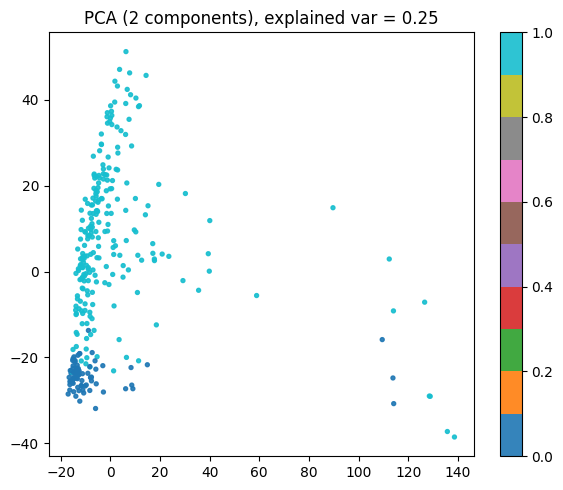

In [12]:
# PCA scatter (Stage 3)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

EMB_DIR = Path("/kaggle/working/embeddings_multi")
train_file = sorted(EMB_DIR.glob("train_concat_*.npz"))[0]
d = np.load(train_file)
X = d["embeddings"].astype(np.float32)
y = d["labels"].astype(int).ravel()

pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(X)
explained = pca.explained_variance_ratio_.sum()
plt.figure(figsize=(6,5))
plt.scatter(Xp[:,0], Xp[:,1], c=y, cmap="tab10", s=8, alpha=0.9)
plt.title(f"PCA (2 components), explained var = {explained:.2f}")
plt.colorbar(); plt.tight_layout()
plt.show()


Loaded embeddings: (312, 384)


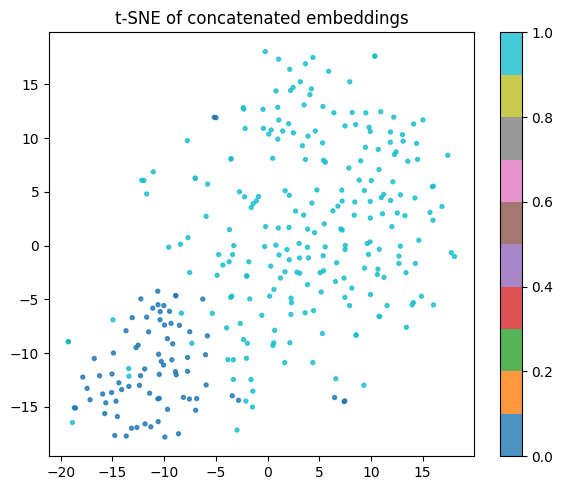

TypeError: check_array() got an unexpected keyword argument 'ensure_all_finite'

In [13]:
# t-SNE and UMAP visualization (Stage 3)
import os, math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE

# paths (adjust if needed)
EMB_DIR = Path("/kaggle/working/embeddings_multi")
train_files = sorted(EMB_DIR.glob("train_concat_*.npz"))
if not train_files:
    raise FileNotFoundError("train_concat_*.npz not found in " + str(EMB_DIR))
train_npz = train_files[0]

data = np.load(train_npz)
X = data["embeddings"].astype(np.float32)
y = data["labels"].astype(int).ravel()
print("Loaded embeddings:", X.shape)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42, n_jobs=8)
X_tsne = tsne.fit_transform(X)
plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="tab10", s=8, alpha=0.8)
plt.title("t-SNE of concatenated embeddings")
plt.colorbar(); plt.tight_layout()
plt.show()

# UMAP (install if missing) - optional, usually better than t-SNE
try:
    import umap
except Exception:
    !pip install -q umap-learn
    import umap
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X)
plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=y, cmap="tab10", s=8, alpha=0.8)
plt.title("UMAP of concatenated embeddings")
plt.colorbar(); plt.tight_layout()
plt.show()

# optional: save figures
out = Path("/kaggle/working/final_stage_outputs"); out.mkdir(exist_ok=True)
plt.savefig(out/"umap_tsne_comparison.png", dpi=200, bbox_inches="tight")
print("Saved to", out)


**Stage 4 : KNOWLEDGE DISTILLATION**

In [14]:
import os
import time
import joblib
import logging
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix)

# CONFIG (edit if you saved elsewhere)
# Where concatenated embeddings and per-backbone reduced embeddings are stored
EMB_DIR = Path("/kaggle/working") / "embeddings_multi"   # default: /kaggle/working/embeddings_multi
EMB_DIR.mkdir(parents=True, exist_ok=True)

# Where previously-trained per-backbone ML models (SVM/XGB/stacking) are stored
MODELS_DIR = Path("/kaggle/working") / "ml_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Output folder for distillation artifacts
OUT_DIR = Path("/kaggle/working") / "distillation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Backbone ordering used to produce concat filenames
BACKBONE_ORDER = ["resnet50", "efficientnetb0", "mobilenetv2"]
CONCAT_TAG = "_".join(BACKBONE_ORDER)

# Concatenated embeddings filenames (expected)
TRAIN_CONCAT = EMB_DIR / f"train_concat_{CONCAT_TAG}.npz"
VAL_CONCAT   = EMB_DIR / f"val_concat_{CONCAT_TAG}.npz"
TEST_CONCAT  = EMB_DIR / f"test_concat_{CONCAT_TAG}.npz"

# manifests saved by Stage 2 (used for label repair)
TRAIN_MANIFEST = Path("/kaggle/working") / "train_manifest.csv"
VAL_MANIFEST   = Path("/kaggle/working") / "val_manifest.csv"
TEST_MANIFEST  = Path("/kaggle/working") / "test_manifest.csv"

# Distillation / training hyperparams
TEMPERATURE = 4.0
ALPHA = 0.7          # weight for soft-target (distillation) loss
BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-3
STUDENT_HIDDEN = [512, 128]
RSEED = 42

tf.random.set_seed(RSEED)
np.random.seed(RSEED)

# Helpers
def load_concat_npz(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    d = np.load(path)
    return d["embeddings"], d["labels"]

def safe_predict_proba(model, X):
    """Return probability array for positive class or None on failure."""
    try:
        # scikit-learn models expose predict_proba; some models may not
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X)
            probs = np.asarray(probs)
            if probs.ndim == 2 and probs.shape[1] >= 2:
                return probs[:, 1]
            return probs.ravel()
        # some sklearn wrappers might provide decision_function only — try to calibrate
        if hasattr(model, "decision_function"):
            scores = model.decision_function(X)
            # convert to probabilistic via sigmoid (approx) if needed
            probs = 1.0 / (1.0 + np.exp(-scores))
            return probs.ravel()
        return None
    except Exception as e:
        print("safe_predict_proba failed:", e)
        return None

def repair_labels_if_mismatch(X, y, split_name):
    """
    Ensure labels length matches X rows. If mismatch, try:
      1) labels from any per-backbone emb .npz matching length
      2) manifest CSV for the split
      3) raise informative error
    """
    if y is not None and len(y) == X.shape[0]:
        return np.array(y, dtype=np.int32)
    print(f"[label-check] MISMATCH for {split_name}: X rows={X.shape[0]}, provided labels length={None if y is None else len(y)}")
    # 1) search per-backbone emb .npz files for matching labels
    for candidate in sorted(EMB_DIR.glob(f"{split_name}_*emb*.npz")):
        try:
            data = np.load(candidate)
            cand_labels = data.get("labels", None)
            if cand_labels is not None and len(cand_labels) == X.shape[0]:
                print(f"[label-check] Recovered labels for {split_name} from {candidate}")
                return cand_labels.astype(np.int32)
        except Exception:
            continue
    # 2) try manifest CSV
    manifest_path = {"train": TRAIN_MANIFEST, "val": VAL_MANIFEST, "test": TEST_MANIFEST}.get(split_name)
    if manifest_path and manifest_path.exists():
        df = pd.read_csv(manifest_path)
        if "label" in df.columns and len(df) == X.shape[0]:
            print(f"[label-check] Recovered labels for {split_name} from manifest {manifest_path}")
            return df.label.values.astype(np.int32)
    # 3) nothing matched
    raise ValueError(f"[label-check] Unable to repair labels for {split_name}. X has {X.shape[0]} rows but provided labels have {None if y is None else len(y)}. "
                     f"Ensure deterministic extraction and correct saved files.")

# Load concatenated embeddings and labels
print("Loading concatenated embeddings ...")
X_train, y_train = load_concat_npz(TRAIN_CONCAT)
X_val,   y_val   = load_concat_npz(VAL_CONCAT)
X_test,  y_test  = load_concat_npz(TEST_CONCAT)
print("Concat shapes (train,val,test):", X_train.shape, X_val.shape, X_test.shape)

# repair labels if necessary
y_train = repair_labels_if_mismatch(X_train, y_train, "train")
y_val   = repair_labels_if_mismatch(X_val,   y_val,   "val")
y_test  = repair_labels_if_mismatch(X_test,  y_test,  "test")
print("Post-repair label shapes:", y_train.shape, y_val.shape, y_test.shape)

# Build or recompute teacher probabilities robustly
teacher_probs_train = teacher_probs_val = teacher_probs_test = None

# 1) Try stacking meta classifier trained on concatenated embeddings
stacking_path = MODELS_DIR / "stacking_meta_logreg.joblib"
if stacking_path.exists():
    print("Trying stacking meta on concatenated embeddings...")
    try:
        teacher_meta = joblib.load(stacking_path)
        pt = safe_predict_proba(teacher_meta, X_train)
        pv = safe_predict_proba(teacher_meta, X_val)
        ptest = safe_predict_proba(teacher_meta, X_test)
        if pt is not None and len(pt) == X_train.shape[0] and pv is not None and len(pv) == X_val.shape[0] and ptest is not None and len(ptest) == X_test.shape[0]:
            teacher_probs_train, teacher_probs_val, teacher_probs_test = pt, pv, ptest
            print("Using stacking meta as teacher (compatible).")
        else:
            print("Stacking meta not compatible or produced mismatched lengths.")
    except Exception as e:
        print("Loading stacking meta failed:", e)

# 2) Fallback: average per-backbone base-model probabilities (SVM/XGB) if available
if teacher_probs_train is None:
    per_train = []; per_val = []; per_test = []
    found_any = False
    for b in BACKBONE_ORDER:
        candidate_names = [MODELS_DIR / f"svm_{b}.joblib", MODELS_DIR / f"xgb_{b}.joblib", MODELS_DIR / f"{b}_clf.joblib"]
        model_path = next((p for p in candidate_names if p.exists()), None)
        if model_path is None:
            print(f"No per-backbone model found for {b} at expected paths; skipping backbone.")
            continue
        try:
            m = joblib.load(model_path)
        except Exception as e:
            print(f"Failed to load model {model_path}: {e}")
            continue

        # prefer reduced emb if exists, else raw emb
        emb_train_file = EMB_DIR / f"train_{b}_emb_reduced.npz"
        emb_val_file   = EMB_DIR / f"val_{b}_emb_reduced.npz"
        emb_test_file  = EMB_DIR / f"test_{b}_emb_reduced.npz"
        if not emb_train_file.exists():
            emb_train_file = EMB_DIR / f"train_{b}_emb.npz"
            emb_val_file   = EMB_DIR / f"val_{b}_emb.npz"
            emb_test_file  = EMB_DIR / f"test_{b}_emb.npz"
            if not emb_train_file.exists():
                print(f"Per-backbone embeddings for {b} not found; skipping.")
                continue

        Xb_train = np.load(emb_train_file)["embeddings"]
        Xb_val   = np.load(emb_val_file)["embeddings"]
        Xb_test  = np.load(emb_test_file)["embeddings"]

        # try to load scaler used for the model
        scaler_path = MODELS_DIR / f"{b}_svm_scaler.joblib"
        if scaler_path.exists():
            try:
                scaler = joblib.load(scaler_path)
                Xb_train_s = scaler.transform(Xb_train)
                Xb_val_s   = scaler.transform(Xb_val)
                Xb_test_s  = scaler.transform(Xb_test)
            except Exception as e:
                print(f"Scaler load/transform failed for {b}: {e}; using raw features.")
                Xb_train_s, Xb_val_s, Xb_test_s = Xb_train, Xb_val, Xb_test
        else:
            Xb_train_s, Xb_val_s, Xb_test_s = Xb_train, Xb_val, Xb_test

        probs_train_b = safe_predict_proba(m, Xb_train_s)
        probs_val_b   = safe_predict_proba(m, Xb_val_s)
        probs_test_b  = safe_predict_proba(m, Xb_test_s)
        if probs_train_b is None:
            print(f"Model {model_path} could not produce probabilities; skipping.")
            continue

        # verify lengths match concatenated arrays
        if not (len(probs_train_b) == X_train.shape[0] and len(probs_val_b) == X_val.shape[0] and len(probs_test_b) == X_test.shape[0]):
            print(f"Length mismatch for backbone {b}: probs_train {len(probs_train_b)} vs concat_train {X_train.shape[0]}; skipping this backbone.")
            continue

        per_train.append(probs_train_b); per_val.append(probs_val_b); per_test.append(probs_test_b)
        found_any = True

    if found_any:
        teacher_probs_train = np.mean(np.vstack(per_train).T, axis=1)
        teacher_probs_val   = np.mean(np.vstack(per_val).T, axis=1)
        teacher_probs_test  = np.mean(np.vstack(per_test).T, axis=1)
        print("Built teacher probs by averaging per-backbone model probabilities. Shapes:", teacher_probs_train.shape)

# 3) If still none, proceed supervised-only (no distillation)
if teacher_probs_train is None:
    use_distillation = False
    print("No teacher probabilities available. Proceeding with supervised-only student training.")
else:
    use_distillation = True
    print("Distillation enabled. Sample teacher probs (train):", teacher_probs_train[:5].tolist())

# Final shape validation for teacher probs (if used)
def validate_shapes(X, y, teacher_probs, split_name="split"):
    if teacher_probs is None:
        if len(y) != X.shape[0]:
            raise ValueError(f"Labels length {len(y)} != X rows {X.shape[0]} for {split_name}")
        return True
    if len(teacher_probs) != X.shape[0] or len(y) != X.shape[0]:
        raise ValueError(f"Mismatch lengths for {split_name}: X={X.shape[0]}, y={len(y)}, teacher_probs={len(teacher_probs)}")
    return True

validate_shapes(X_train, y_train, teacher_probs_train, "train")
validate_shapes(X_val, y_val, teacher_probs_val, "val")
validate_shapes(X_test, y_test, teacher_probs_test, "test")
print("Shape validation passed.")

# Build TF datasets (aligned)
def make_tf_dataset(X, y, teacher_probs=None, batch=BATCH_SIZE, shuffle=False):
    if teacher_probs is None:
        ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.int32)))
    else:
        ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.int32), teacher_probs.astype(np.float32)))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=RSEED)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_emb = make_tf_dataset(X_train, y_train, teacher_probs=(teacher_probs_train if use_distillation else None), shuffle=True)
val_ds_emb   = make_tf_dataset(X_val,   y_val,   teacher_probs=(teacher_probs_val if use_distillation else None), shuffle=False)
test_ds_emb  = make_tf_dataset(X_test,  y_test,  teacher_probs=(teacher_probs_test if use_distillation else None), shuffle=False)
print("Datasets created. Example element_spec:", train_ds_emb.element_spec)

#  Build student MLP 
def build_student(input_dim, hidden=[512,128], dropout=0.3):
    inp = layers.Input(shape=(input_dim,), name="emb_in")
    x = inp
    for h in hidden:
        x = layers.Dense(h, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    model = models.Model(inputs=inp, outputs=out, name="student_mlp")
    return model

student = build_student(X_train.shape[1], hidden=STUDENT_HIDDEN, dropout=0.3)
student.summary()

# Distillation loss helper
eps = 1e-7
def distillation_loss_fn(y_true, y_pred, teacher_probs_batch, T=1.0, alpha=0.5):
    """
    y_true: shape (batch, 1) float32
    y_pred: student probabilities shape (batch, 1) float32
    teacher_probs_batch: teacher probabilities shape (batch, 1) float32
    """
    # clip for numerical stability
    p_s = tf.clip_by_value(y_pred, eps, 1.0 - eps)          # student prob
    p_t = tf.clip_by_value(teacher_probs_batch, eps, 1.0 - eps)  # teacher prob

    # convert to logits, apply temperature, then back to softened probabilities
    logit_s = tf.math.log(p_s / (1.0 - p_s))
    logit_t = tf.math.log(p_t / (1.0 - p_t))
    s_soft = tf.nn.sigmoid(logit_s / T)
    t_soft = tf.nn.sigmoid(logit_t / T)

    # KLD between Bernoulli distributions
    kld = t_soft * tf.math.log((t_soft + eps) / (s_soft + eps)) \
          + (1.0 - t_soft) * tf.math.log(((1.0 - t_soft) + eps) / ((1.0 - s_soft) + eps))
    kld = tf.reduce_mean(kld)

    # supervised BCE (student outputs probabilities)
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))

    # combine (note multiplication by T^2 for distillation scale)
    loss = alpha * (T * T) * kld + (1.0 - alpha) * bce
    return loss

# Custom DistillModel (wrap student)
class DistillModel(tf.keras.Model):
    def __init__(self, student_model, T=1.0, alpha=0.5, **kwargs):
        super().__init__(**kwargs)
        self.student = student_model
        self.T = T
        self.alpha = alpha

    def compile(self, optimizer, metrics=None):
        super().compile()
        self.optimizer = optimizer
        # Use from_logits=False since student outputs probabilities
        self.loss_fn_bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
        self.train_metrics = metrics or []

    @tf.function
    def train_step(self, data):
        if len(data) == 3:
            x, y, t_probs = data
        else:
            x, y = data
            t_probs = None

        y_true_reshaped = tf.expand_dims(tf.cast(y, tf.float32), axis=-1)

        with tf.GradientTape() as tape:
            y_pred = self.student(x, training=True)

            if t_probs is not None:
                t_probs_reshaped = tf.expand_dims(tf.cast(t_probs, tf.float32), axis=-1)
                loss = distillation_loss_fn(y_true_reshaped, y_pred, t_probs_reshaped, T=self.T, alpha=self.alpha)
            else:
                loss = tf.reduce_mean(self.loss_fn_bce(y_true_reshaped, y_pred))

        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        results = {"loss": loss}
        for m in self.train_metrics:
            m.update_state(y_true_reshaped, y_pred)
            results[m.name] = m.result()
        return results

    @tf.function
    def test_step(self, data):
        if len(data) == 3:
            x, y, t_probs = data
        else:
            x, y = data
            t_probs = None

        y_true_reshaped = tf.expand_dims(tf.cast(y, tf.float32), axis=-1)
        y_pred = self.student(x, training=False)
        loss = tf.reduce_mean(self.loss_fn_bce(y_true_reshaped, y_pred))
        results = {"loss": loss}
        for m in self.train_metrics:
            m.update_state(y_true_reshaped, y_pred)
            results[m.name] = m.result()
        return results

# Custom checkpoint callback 
class CustomStudentModelCheckpoint(callbacks.Callback):
    def __init__(self, filepath, monitor='val_loss', verbose=0,
                 save_best_only=False, save_weights_only=False, mode='auto', **kwargs):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.verbose = verbose
        self.save_best_only = save_best_only
        self.save_weights_only = save_weights_only
        self.mode = mode

        if self.mode == 'auto':
            if 'loss' in self.monitor or 'error' in self.monitor:
                self.monitor_op = lambda a, b: a < b
                self.best = np.inf
            else:
                self.monitor_op = lambda a, b: a > b
                self.best = -np.inf
        elif self.mode == 'min':
            self.monitor_op = lambda a, b: a < b
            self.best = np.inf
        else:
            self.monitor_op = lambda a, b: a > b
            self.best = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            if self.verbose:
                print(f"Warning: {self.monitor} is not available in logs; skipping checkpoint.")
            return

        improved = self.monitor_op(current, self.best)
        if self.save_best_only:
            if improved:
                if self.verbose:
                    print(f"\nEpoch {epoch+1}: {self.monitor} improved from {self.best:.6f} to {current:.6f}. Saving student to {self.filepath}")
                self.best = current
                if self.save_weights_only:
                    self.model.student.save_weights(self.filepath, overwrite=True)
                else:
                    # save full model (no optimizer) for portability
                    self.model.student.save(self.filepath, overwrite=True, include_optimizer=False)
            else:
                if self.verbose:
                    print(f"\nEpoch {epoch+1}: {self.monitor} did not improve ({current:.6f} vs best {self.best:.6f}).")
        else:
            if self.verbose:
                print(f"\nEpoch {epoch+1}: saving student to {self.filepath}")
            if self.save_weights_only:
                self.model.student.save_weights(self.filepath, overwrite=True)
            else:
                self.model.student.save(self.filepath, overwrite=True, include_optimizer=False)

# Compile & train
distill = DistillModel(student, T=TEMPERATURE, alpha=ALPHA)
opt = optimizers.Adam(learning_rate=LR)
metrics = [tf.keras.metrics.BinaryAccuracy(name='accuracy'),
           tf.keras.metrics.AUC(name='auc'),
           tf.keras.metrics.Precision(name='precision'),
           tf.keras.metrics.Recall(name='recall')]
distill.compile(optimizer=opt, metrics=metrics)

es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
ckpt_path = OUT_DIR / f"student_best_{int(time.time())}.h5"
mc = CustomStudentModelCheckpoint(str(ckpt_path), monitor='val_loss', save_best_only=True, verbose=1, mode='auto')

print("Starting distillation training. use_distillation=", use_distillation)
history = distill.fit(train_ds_emb, validation_data=val_ds_emb, epochs=EPOCHS, callbacks=[es, mc])

# Load best student and evaluate on test set
if ckpt_path.exists():
    best_student = tf.keras.models.load_model(str(ckpt_path), compile=False)
else:
    print("Checkpoint not found; using current student weights.")
    best_student = student

y_predp = best_student.predict(X_test, batch_size=BATCH_SIZE).ravel()
y_pred = (y_predp >= 0.5).astype(int)

print("\nStudent Test metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
try:
    print("AUC:", roc_auc_score(y_test, y_predp))
except Exception:
    print("AUC: not available.")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred, digits=4))

# Save artifacts
final_path = OUT_DIR / f"student_final_{int(time.time())}.h5"
best_student.save(final_path)
pd.DataFrame(history.history).to_csv(OUT_DIR / "student_history.csv", index=False)
print("Saved final student model to:", final_path)
print("Saved training history CSV to:", OUT_DIR / "student_history.csv")

# Quick compare teacher vs student on sample (if teacher existed)
if use_distillation:
    print("\nSample comparison (first 6 test indices):")
    for i in range(min(6, len(y_test))):
        print(f" idx={i} teacher_prob={float(teacher_probs_test[i]):.4f} student_prob={float(y_predp[i]):.4f} label={int(y_test[i])}")
print("Stage 4 complete.")


Loading concatenated embeddings ...
Concat shapes (train,val,test): (312, 384) (86, 384) (171, 384)
Post-repair label shapes: (312,) (86,) (171,)
No per-backbone model found for resnet50 at expected paths; skipping backbone.
No per-backbone model found for efficientnetb0 at expected paths; skipping backbone.
No per-backbone model found for mobilenetv2 at expected paths; skipping backbone.
No teacher probabilities available. Proceeding with supervised-only student training.
Shape validation passed.
Datasets created. Example element_spec: (TensorSpec(shape=(None, 384), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


Model: "student_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ emb_in (InputLayer)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,473 (1.01 MB)

 Trainable params: 264,193 (1.01 MB)

 Non-trainable params: 1,280 (5.00 KB)

Starting distillation training. use_distillation= False
Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.6141 - auc: 0.7383 - loss: 0.6113 - precision: 0.8712 - recall: 0.5781


Epoch 1: val_loss improved from inf to 0.000000. Saving student to /kaggle/working/distillation/student_best_1764538929.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 432ms/step - accuracy: 0.6235 - auc: 0.7488 - loss: 0.5557 - precision: 0.8755 - recall: 0.5873 - val_accuracy: 0.9302 - val_auc: 0.9805 - val_loss: 0.0000e+00 - val_precision: 1.0000 - val_recall: 0.9062
Epoch 2/40
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 0.2510 - precision: 1.0000 - recall: 0.8333
Epoch 2: val_loss did not improve (0.000000 vs best 0.000000).
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8940 - auc: 0.9897 - loss: 0.2659 - precision: 0.9978 - recall: 0.8644 - val_accuracy: 0.9186 - val_auc: 0.9766 - val_loss: 0.0000e+00 - val_precision: 1.0000 - val_recall: 0.8906
Epoch 3/40
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9062 - auc: 1.0000 - loss: 0.2757 - precision: 1.0000 - recall: 0.8889
Epoch 3: val_loss did not improve (0.000000 vs best 0.000000).
10/10 ━━━━━━


Student Test metrics:
Accuracy: 0.9298245614035088
Precision: 0.9914529914529915
Recall: 0.9133858267716536
F1: 0.9508196721311475
AUC: 0.9668933428775949
Confusion matrix:
 [[ 43   1]
 [ 11 116]]
Classification report:
               precision    recall  f1-score   support

           0     0.7963    0.9773    0.8776        44
           1     0.9915    0.9134    0.9508       127

    accuracy                         0.9298       171
   macro avg     0.8939    0.9453    0.9142       171
weighted avg     0.9412    0.9298    0.9320       171

Saved final student model to: /kaggle/working/distillation/student_final_1764538938.h5
Saved training history CSV to: /kaggle/working/distillation/student_history.csv
Stage 4 complete.


**STAGE 5: ATTACH ML MODELS (SVM / KNN / XGBOOST / Voting)**

In [16]:
import os, joblib, time
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve, auc)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Try import xgboost safely
try:
    import xgboost as xgb
except Exception:
    xgb = None
    print("xgboost not available in this environment. Install it if you want to use XGBoost models.")

# CONFIG
EMB_DIR = Path("/kaggle/working") / "embeddings_multi"   # must contain train_concat_...npz etc.
MODELS_DIR = Path("/kaggle/working") / "ml_models"; MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = MODELS_DIR
RESULTS_DIR = OUT_DIR / "stage5_results"; RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE_ORDER = ["resnet50","efficientnetb0","mobilenetv2"]
CONCAT_TAG = "_".join(BACKBONE_ORDER)
TRAIN_CONCAT = EMB_DIR / f"train_concat_{CONCAT_TAG}.npz"
VAL_CONCAT   = EMB_DIR / f"val_concat_{CONCAT_TAG}.npz"
TEST_CONCAT  = EMB_DIR / f"test_concat_{CONCAT_TAG}.npz"

RSEED = 42
np.random.seed(RSEED)

# Helpers
def load_concat_npz(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    d = np.load(path)
    return d["embeddings"], d["labels"]

print("Loading concatenated embeddings...")
X_train, y_train = load_concat_npz(TRAIN_CONCAT)
X_val,   y_val   = load_concat_npz(VAL_CONCAT)
X_test,  y_test  = load_concat_npz(TEST_CONCAT)
print("Shapes - train, val, test:", X_train.shape, X_val.shape, X_test.shape)

# Sanity convert to numpy and correct shapes
X_train = np.array(X_train, dtype=np.float32)
X_val   = np.array(X_val, dtype=np.float32)
X_test  = np.array(X_test, dtype=np.float32)
y_train = np.array(y_train).astype(int).ravel()
y_val   = np.array(y_val).astype(int).ravel()
y_test  = np.array(y_test).astype(int).ravel()

# Basic checks
assert X_train.shape[0] == y_train.shape[0], "Train shapes mismatch"
assert X_val.shape[0]   == y_val.shape[0],   "Val shapes mismatch"
assert X_test.shape[0]  == y_test.shape[0],  "Test shapes mismatch"

# Scale features 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Save scaler
scaler_path = MODELS_DIR / "scaler_concat.joblib"
joblib.dump(scaler, scaler_path)
print("Saved StandardScaler to", scaler_path)

# Compute class weights
classes_unique = np.unique(y_train)
class_weights_arr = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes_unique, class_weights_arr)}
print("Class weights:", class_weights)

# Compute scale_pos_weight for xgboost: ratio (neg/pos)
if xgb is not None:
    # careful: xgboost expects ratio of negative to positive examples
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    if n_pos > 0:
        scale_pos_weight = float(n_neg) / float(n_pos)
    else:
        scale_pos_weight = 1.0
    print("XGBoost scale_pos_weight set to:", scale_pos_weight)
else:
    scale_pos_weight = 1.0

# Train classifiers
# SVM (RBF) - with probability=True to support soft voting
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RSEED, C=1.0, gamma='scale')
print("Training SVM...")
svm.fit(X_train_s, y_train)
print("SVM trained.")

# KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("Training KNN...")
knn.fit(X_train_s, y_train)
print("KNN trained.")

# XGBoost (only if available)
if xgb is not None:
    xgb_clf = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RSEED,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1
    )
    print("Training XGBoost...")
    xgb_clf.fit(X_train_s, y_train, verbose=False)
    print("XGBoost trained. Best iteration attribute (if available):", getattr(xgb_clf, "best_iteration", None))
else:
    xgb_clf = None
    print("Skipping XGBoost training since xgboost not available.")

# Save individual models
joblib.dump(svm, MODELS_DIR / "svm_concat.joblib")
joblib.dump(knn, MODELS_DIR / "knn_concat.joblib")
if xgb_clf is not None:
    joblib.dump(xgb_clf, MODELS_DIR / "xgb_concat.joblib")
print("Saved svm/knn/(xgb) models to", MODELS_DIR)

# Voting Ensemble (soft) ----------------
estimators = [('svm', svm), ('knn', knn)]
if xgb_clf is not None:
    estimators.append(('xgb', xgb_clf))

voting = VotingClassifier(
    estimators=estimators,
    voting='soft',  # requires predict_proba
    n_jobs=-1
)
print("Fitting VotingClassifier (soft vote) on train set...")
voting.fit(X_train_s, y_train)
joblib.dump(voting, MODELS_DIR / "voting_concat.joblib")
print("Saved voting model to", MODELS_DIR / "voting_concat.joblib")

# Evaluation helper
def eval_and_report(name, model, Xs, ys, results_dir=RESULTS_DIR):
    proba = None
    scores = None
    try:
        proba = model.predict_proba(Xs)
        proba = np.asarray(proba)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            scores = proba[:,1]
        else:
            scores = proba.ravel()
    except Exception:
        try:
            df = model.decision_function(Xs)
            scores = 1.0 / (1.0 + np.exp(-df))
        except Exception:
            scores = None

    ypred = model.predict(Xs)
    acc = accuracy_score(ys, ypred)
    prec = precision_score(ys, ypred, zero_division=0)
    rec = recall_score(ys, ypred, zero_division=0)
    f1 = f1_score(ys, ypred, zero_division=0)
    roc_auc = roc_auc_score(ys, scores) if (scores is not None and len(np.unique(ys))>1) else None

    print(f"\n== {name} Evaluation ==")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("AUC:", roc_auc)
    print("Confusion matrix:\n", confusion_matrix(ys, ypred))
    print("Classification report:\n", classification_report(ys, ypred, digits=4))

    # Save metrics
    metrics = {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": roc_auc,
        "n_samples": len(ys)
    }
    mf = Path(results_dir) / f"{name}_metrics.csv"
    pd.DataFrame([metrics]).to_csv(mf, index=False)

    # Save predictions
    preds_df = pd.DataFrame({"y_true": ys, "y_pred": ypred})
    if scores is not None:
        preds_df["y_score"] = scores
    preds_df.to_csv(Path(results_dir) / f"{name}_preds.csv", index=False)

    # ROC plot if scores available
    if scores is not None:
        fpr, tpr, _ = roc_curve(ys, scores)
        roc_auc_val = auc(fpr, tpr)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.4f})')
        plt.plot([0,1],[0,1],'k--', alpha=0.4)
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC - {name}')
        plt.legend(loc='lower right')
        plt.grid(alpha=0.2)
        plt.savefig(Path(results_dir) / f"{name}_roc.png", bbox_inches='tight')
        plt.close()

    return metrics

# Evaluate models on val and test
models_to_eval = {
    "SVM": svm,
    "KNN": knn,
}
if xgb_clf is not None:
    models_to_eval["XGBoost"] = xgb_clf
models_to_eval["Voting"] = voting

eval_records = []
for name, model in models_to_eval.items():
    print("\n*** VALIDATION SET EVAL FOR:", name)
    mval = eval_and_report(name + "_val", model, X_val_s, y_val)
    print("\n*** TEST SET EVAL FOR:", name)
    mtest = eval_and_report(name + "_test", model, X_test_s, y_test)
    eval_records.append((name, mval, mtest))

# Save summary CSV for all models on test
rows = []
for name, mval, mtest in eval_records:
    rows.append({
        "model": name,
        "val_accuracy": mval["accuracy"], "val_precision": mval["precision"], "val_recall": mval["recall"], "val_f1": mval["f1"], "val_auc": mval["auc"],
        "test_accuracy": mtest["accuracy"], "test_precision": mtest["precision"], "test_recall": mtest["recall"], "test_f1": mtest["f1"], "test_auc": mtest["auc"]
    })
pd.DataFrame(rows).to_csv(Path(RESULTS_DIR) / "models_summary_test.csv", index=False)
print("Saved models summary to", Path(RESULTS_DIR) / "models_summary_test.csv")

# Save XGBoost feature importance (if available)
if xgb_clf is not None:
    try:
        fi = xgb_clf.get_booster().get_score(importance_type='gain')
        fi_df = pd.DataFrame(list(fi.items()), columns=['feature','gain']).sort_values('gain', ascending=False)
        fi_df.to_csv(Path(RESULTS_DIR) / "xgb_feature_importance.csv", index=False)
        print("Saved XGBoost feature importance to", Path(RESULTS_DIR) / "xgb_feature_importance.csv")
    except Exception as e:
        print("Could not extract XGBoost feature importance:", e)

print("Stage 5 complete. Models and results saved in:", RESULTS_DIR)


Loading concatenated embeddings...
Shapes - train, val, test: (312, 384) (86, 384) (171, 384)
Saved StandardScaler to /kaggle/working/ml_models/scaler_concat.joblib
Class weights: {0: 1.9259259259259258, 1: 0.6753246753246753}
XGBoost scale_pos_weight set to: 0.35064935064935066
Training SVM...
SVM trained.
Training KNN...
KNN trained.
Training XGBoost...
XGBoost trained. Best iteration attribute (if available): None
Saved svm/knn/(xgb) models to /kaggle/working/ml_models
Fitting VotingClassifier (soft vote) on train set...
Saved voting model to /kaggle/working/ml_models/voting_concat.joblib

*** VALIDATION SET EVAL FOR: SVM

== SVM_val Evaluation ==
Accuracy: 0.9651162790697675
Precision: 1.0
Recall: 0.953125
F1: 0.976
AUC: 0.9985795454545455
Confusion matrix:
 [[22  0]
 [ 3 61]]
Classification report:
               precision    recall  f1-score   support

           0     0.8800    1.0000    0.9362        22
           1     1.0000    0.9531    0.9760        64

    accuracy        

**STAGE 6: HYBRID ENSEMBLE / STACKING**

In [17]:
# Loads concatenated embeddings, classical models, and the student model
# Trains a logistic-regression stacking meta-model and evaluates fusion variants
# Saves stacked meta model and comparison CSV in /kaggle/working/hybrid_models

import os, joblib, time, glob
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

# CONFIG (edit if necessary)
EMB_DIR = Path("/kaggle/working") / "embeddings_multi"
MODELS_DIR = Path("/kaggle/working") / "ml_models"
OUT_DIR = Path("/kaggle/working") / "hybrid_models"; OUT_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE_ORDER = ["resnet50","efficientnetb0","mobilenetv2"]
CONCAT_TAG = "_".join(BACKBONE_ORDER)

TRAIN_CONCAT = EMB_DIR / f"train_concat_{CONCAT_TAG}.npz"
VAL_CONCAT   = EMB_DIR / f"val_concat_{CONCAT_TAG}.npz"
TEST_CONCAT  = EMB_DIR / f"test_concat_{CONCAT_TAG}.npz"

# Helper: safe loads
def load_concat_npz(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    d = np.load(path)
    return d["embeddings"], d["labels"]

print("Loading concatenated embeddings...")
X_train, y_train = load_concat_npz(TRAIN_CONCAT)
X_val,   y_val   = load_concat_npz(VAL_CONCAT)
X_test,  y_test  = load_concat_npz(TEST_CONCAT)
print("Shapes - train, val, test:", X_train.shape, X_val.shape, X_test.shape)

# Ensure arrays are numpy and correct dtype
X_train = np.asarray(X_train, dtype=np.float32)
X_val   = np.asarray(X_val, dtype=np.float32)
X_test  = np.asarray(X_test, dtype=np.float32)
y_train = np.asarray(y_train).astype(int).ravel()
y_val   = np.asarray(y_val).astype(int).ravel()
y_test  = np.asarray(y_test).astype(int).ravel()

# Load classical models (if present)
models = {}
candidates = {
    "svm": MODELS_DIR / "svm_concat.joblib",
    "knn": MODELS_DIR / "knn_concat.joblib",
    "xgb": MODELS_DIR / "xgb_concat.joblib",
    "voting": MODELS_DIR / "voting_concat.joblib"
}
for name, p in candidates.items():
    if p.exists():
        try:
            models[name] = joblib.load(p)
            print(f"Loaded {name} from {p}")
        except Exception as e:
            print(f"Failed to load {p}: {e}")
    else:
        print(f"No model file for {name} at {p} (skipping)")

if len(models) == 0:
    raise RuntimeError("No classical models loaded. Run Stage 5 first or place models in MODELS_DIR.")

# Load student model (pick latest saved student_final_*.h5 or student_best_*.h5)
distill_dir = Path("/kaggle/working") / "distillation"
if distill_dir.exists():
    cand = sorted(list(distill_dir.glob("student_final_*.h5")) + list(distill_dir.glob("student_best_*.h5")))
    if len(cand) == 0:
        raise FileNotFoundError(f"No student model found in {distill_dir}. Run Stage 4 first.")
    STUDENT_MODEL_PATH = cand[-1]
else:
    raise FileNotFoundError(f"Distillation folder not found: {distill_dir}")

print("Using Student Model:", STUDENT_MODEL_PATH)
student_model = tf.keras.models.load_model(str(STUDENT_MODEL_PATH), compile=False)

def student_predict_proba(X):
    # student expects concatenated embeddings in original scale (not necessarily standardized)
    # model outputs probability (sigmoid) shape (N,1)
    p = student_model.predict(X, verbose=0).ravel()
    return p

# Get probabilities from classical models
scaler_path = MODELS_DIR / "scaler_concat.joblib"
if scaler_path.exists():
    scaler = joblib.load(scaler_path)
    X_train_s = scaler.transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)
    print("Applied scaler from", scaler_path)
else:
    # fallback: use raw embeddings (best to use the same scaler used during training)
    X_train_s, X_val_s, X_test_s = X_train, X_val, X_test
    print("No scaler found; using raw embeddings for classical models (may affect probabilities).")

def get_model_probas(model_dict, Xs):
    out = {}
    for name, m in model_dict.items():
        try:
            probs = m.predict_proba(Xs)[:,1]
        except Exception:
            # try decision_function -> sigmoid
            if hasattr(m, "decision_function"):
                df = m.decision_function(Xs)
                probs = 1.0 / (1.0 + np.exp(-df))
            else:
                raise RuntimeError(f"Model {name} cannot produce probabilities.")
        out[name] = probs
    return out

train_cl = get_model_probas(models, X_train_s)
val_cl   = get_model_probas(models, X_val_s)
test_cl  = get_model_probas(models, X_test_s)
print("Collected classical model probs for:", list(train_cl.keys()))

# Student probs
train_student = student_predict_proba(X_train)
val_student   = student_predict_proba(X_val)
test_student  = student_predict_proba(X_test)

# Build meta features (sorted model names for consistency) 
def stack_features(classical_probs, student_probs):
    names = sorted(classical_probs.keys())
    parts = [classical_probs[n] for n in names] + [student_probs]
    X_meta = np.vstack(parts).T
    cols = names + ["student"]
    return X_meta, cols

X_meta_train, meta_cols = stack_features(train_cl, train_student)
X_meta_val,   _         = stack_features(val_cl, val_student)
X_meta_test,  _         = stack_features(test_cl, test_student)
print("Meta columns:", meta_cols, "Meta-train shape:", X_meta_train.shape)

# Train logistic-regression stacking meta-model
meta = LogisticRegression(max_iter=2000, random_state=42)
meta.fit(X_meta_train, y_train)
joblib.dump(meta, OUT_DIR / "stacking_meta_logreg.joblib")
print("Saved stacking meta model to:", OUT_DIR / "stacking_meta_logreg.joblib")

# Evaluate helper
def evaluate(name, y_true, y_score):
    y_pred = (y_score >= 0.5).astype(int)
    print(f"\n=== {name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1 Score :", f1_score(y_true, y_pred, zero_division=0))
    try:
        print("AUC      :", roc_auc_score(y_true, y_score))
    except Exception:
        print("AUC      : None")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Report:\n", classification_report(y_true, y_pred, digits=4))

meta_val_score  = meta.predict_proba(X_meta_val)[:,1]
meta_test_score = meta.predict_proba(X_meta_test)[:,1]
evaluate("Stacking Meta (Val)", y_val, meta_val_score)
evaluate("Stacking Meta (Test)", y_test, meta_test_score)

#  Weighted Fusion (student + voting or another ensemble)
if "voting" in train_cl:
    voting_val = val_cl["voting"]
    voting_test = test_cl["voting"]
else:
    # if voting not present, pick the first available model as ensemble proxy
    first_name = sorted(train_cl.keys())[0]
    voting_val = val_cl[first_name]
    voting_test = test_cl[first_name]

best_w = None
best_auc = -1.0
for w in np.linspace(0,1,21):
    fused_val = w * val_student + (1.0 - w) * voting_val
    try:
        auc_val = roc_auc_score(y_val, fused_val)
    except Exception:
        auc_val = -1.0
    if auc_val > best_auc:
        best_auc = auc_val
        best_w = w

print(f"\nBest fusion weight (student={best_w:.2f}) on val AUC={best_auc:.4f}")
fused_test = best_w * test_student + (1.0 - best_w) * voting_test
evaluate(f"Weighted Fusion (w={best_w:.2f})", y_test, fused_test)

# Save comparison CSV
rows = []
def safe_auc(y, s):
    try:
        return float(roc_auc_score(y, s))
    except:
        return None

rows.append({"model": "stacking_meta", "auc": safe_auc(y_test, meta_test_score)})
rows.append({"model": "weighted_fusion", "auc": safe_auc(y_test, fused_test)})
rows.append({"model": "student", "auc": safe_auc(y_test, test_student)})
for name, probs in test_cl.items():
    rows.append({"model": name, "auc": safe_auc(y_test, probs)})

pd.DataFrame(rows).to_csv(OUT_DIR / "hybrid_comparison.csv", index=False)
print("Saved hybrid comparison to:", OUT_DIR / "hybrid_comparison.csv")

print("Stage 6 complete.")


Loading concatenated embeddings...
Shapes - train, val, test: (312, 384) (86, 384) (171, 384)
Loaded svm from /kaggle/working/ml_models/svm_concat.joblib
Loaded knn from /kaggle/working/ml_models/knn_concat.joblib
Loaded xgb from /kaggle/working/ml_models/xgb_concat.joblib
Loaded voting from /kaggle/working/ml_models/voting_concat.joblib
Using Student Model: /kaggle/working/distillation/student_final_1764538938.h5
Applied scaler from /kaggle/working/ml_models/scaler_concat.joblib
Collected classical model probs for: ['svm', 'knn', 'xgb', 'voting']
Meta columns: ['knn', 'svm', 'voting', 'xgb', 'student'] Meta-train shape: (312, 5)
Saved stacking meta model to: /kaggle/working/hybrid_models/stacking_meta_logreg.joblib

=== Stacking Meta (Val) ===
Accuracy : 0.9651162790697675
Precision: 1.0
Recall   : 0.953125
F1 Score : 0.976
AUC      : 0.9985795454545454
Confusion Matrix:
 [[22  0]
 [ 3 61]]
Report:
               precision    recall  f1-score   support

           0     0.8800    1.00

******STAGE 7 PREDICTION ENTRYPOINT + SEVERITY INDEX CSV******

In [21]:
import os, time, joblib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import applications, Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from PIL import Image
import cv2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# CONFIG
WORK = Path("/kaggle/working")
EMB_DIR = WORK / "embeddings_multi"
MODELS_DIR = WORK / "ml_models"
HYBRID_DIR = WORK / "hybrid_models"
DISTILL_DIR = WORK / "distillation"
OUT_DIR = WORK / "predictions"; OUT_DIR.mkdir(exist_ok=True, parents=True)
XAI_OUT = WORK / "xai_outputs"; XAI_OUT.mkdir(exist_ok=True, parents=True)

BACKBONE_ORDER = ["resnet50", "efficientnetb0", "mobilenetv2"]
IMG_SIZE = 224
BATCH_SIZE = 8
IMAGENET_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)
CONCAT_TAG = "_".join(BACKBONE_ORDER)

# classical & stacking paths (may or may not exist)
CLASSICAL_MODELS = {
    "svm": MODELS_DIR / "svm_concat.joblib",
    "knn": MODELS_DIR / "knn_concat.joblib",
    "xgb": MODELS_DIR / "xgb_concat.joblib",
    "voting": MODELS_DIR / "voting_concat.joblib"
}
STACKING_META_PATH = HYBRID_DIR / "stacking_meta_logreg.joblib"
SCALER_PATH = MODELS_DIR / "scaler_concat.joblib"

# latest student model (if present)
STUDENT_PATH = None
if Path(DISTILL_DIR).exists():
    cand = sorted(list(Path(DISTILL_DIR).glob("student_final_*.h5")) + list(Path(DISTILL_DIR).glob("student_best_*.h5")))
    if len(cand)>0:
        STUDENT_PATH = cand[-1]

#  USAGE - Option A (paste absolute image paths here, one per line)
PATHS_INPUT = """
/kaggle/input/scd-for-fyp/1.jpg
/kaggle/input/scd-for-fyp/16.jpg
/kaggle/input/scd-for-fyp/17.jpg
/kaggle/input/scd-for-fyp/2.jpg
""".strip()

# Option B: you can set PATHS_LIST = ["/full/path/1.jpg","/full/path/2.jpg",...]
PATHS_LIST = None

# Helper utilities
def parse_paths_input(input_value):
    if PATHS_LIST:
        return [str(Path(p).resolve()) for p in PATHS_LIST]
    if input_value is None:
        return []
    s = str(input_value).strip()
    if "\n" in s:
        parts = [line.strip() for line in s.splitlines() if line.strip()]
        return [str(Path(p).resolve()) for p in parts]
    if "," in s:
        parts = [p.strip() for p in s.split(",") if p.strip()]
        return [str(Path(p).resolve()) for p in parts]
    return [str(Path(s).resolve())]

# Preprocess single image -> normalized array for backbone input
def preprocess_image_np(path):
    img = tf.io.read_file(str(path))
    try:
        img = tf.io.decode_jpeg(img, channels=3)
    except Exception:
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img.numpy()

# Build backbone feature extractor that outputs GAP features
def build_backbone_feat_extractor(name):
    n = name.lower()
    if n == "resnet50":
        base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    elif n == "efficientnetb0":
        base = applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    elif n == "mobilenetv2":
        base = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    else:
        raise ValueError("Unknown backbone " + name)
    x = base.output
    x = GlobalAveragePooling2D()(x)
    model = Model(inputs=base.input, outputs=x, name=f"{name}_featex")
    return model

# Extract embeddings for a batch (all images at once) for each backbone
def extract_image_embeddings_batch(img_paths, backbones=BACKBONE_ORDER, batch_size=BATCH_SIZE):
    imgs = [preprocess_image_np(p) for p in img_paths]
    imgs = np.stack(imgs, axis=0).astype(np.float32)
    results = {}
    for b in backbones:
        feat_model = build_backbone_feat_extractor(b)
        feats = feat_model.predict(imgs, batch_size=batch_size, verbose=0)
        results[b] = feats.astype(np.float32)
        # free memory between backbone runs
        tf.keras.backend.clear_session()
    return results

# Try load saved per-backbone scaler+pca (if not present, we'll try auto-fit)
def load_saved_scaler_pca(emb_dir, backbone):
    pca_path = Path(emb_dir) / f"pca_{backbone}.joblib"
    scl_path = Path(emb_dir) / f"scaler_{backbone}.joblib"
    if pca_path.exists() and scl_path.exists():
        try:
            return joblib.load(scl_path), joblib.load(pca_path)
        except Exception:
            return None, None
    return None, None

# Auto-fit scaler+pca on raw train_{backbone}_emb.npz and cache them
def load_auto_raw_pipeline(emb_dir, backbone, target_dim):
    auto_scl_path = Path(emb_dir) / f"auto_scaler_raw_{backbone}.joblib"
    auto_pca_path = Path(emb_dir) / f"auto_pca_raw_{backbone}.joblib"
    if auto_scl_path.exists() and auto_pca_path.exists():
        try:
            return joblib.load(auto_scl_path), joblib.load(auto_pca_path)
        except Exception:
            pass
    raw_train = Path(emb_dir) / f"train_{backbone}_emb.npz"
    if not raw_train.exists():
        return None, None
    data = np.load(raw_train)
    Xraw = data["embeddings"].astype(np.float32)
    scl = StandardScaler().fit(Xraw)
    max_comp = min(target_dim, Xraw.shape[1], Xraw.shape[0])
    if max_comp <= 0:
        return None, None
    pca = PCA(n_components=max_comp, random_state=42).fit(scl.transform(Xraw))
    try:
        joblib.dump(scl, auto_scl_path)
        joblib.dump(pca, auto_pca_path)
    except Exception:
        pass
    return scl, pca

# Infer expected per-backbone dims from global concat scaler if available, else default 128
def infer_expected_dims_from_global_scaler(models_dir, backbone_order):
    global_scaler_path = Path(models_dir) / "scaler_concat.joblib"
    if global_scaler_path.exists():
        try:
            gsc = joblib.load(global_scaler_path)
            num = getattr(gsc, "n_features_in_", None)
            if num is None:
                num = int(getattr(gsc, "mean_", np.zeros(len(backbone_order)*128)).shape[0])
            total = int(num)
        except Exception:
            total = 128 * len(backbone_order)
    else:
        total = 128 * len(backbone_order)
    per = total // len(backbone_order)
    leftover = total - per * len(backbone_order)
    expected_dims = {}
    for i,b in enumerate(backbone_order):
        expected_dims[b] = per + (1 if i < leftover else 0)
    return expected_dims

_expected_dims = infer_expected_dims_from_global_scaler(MODELS_DIR, BACKBONE_ORDER)

# Transform per-backbone raw features to expected dims, using saved pipelines or auto-fit fallback
def transform_backbone_feat(feat_arr, backbone):
    saved_scl, saved_pca = load_saved_scaler_pca(EMB_DIR, backbone)
    raw_dim = feat_arr.shape[1]
    def scl_in_features(scl_obj):
        try:
            return int(getattr(scl_obj, "n_features_in_", scl_obj.mean_.shape[0]))
        except Exception:
            return None
    if saved_scl is not None and saved_pca is not None:
        if scl_in_features(saved_scl) == raw_dim:
            try:
                Xs = saved_scl.transform(feat_arr)
                Xp = saved_pca.transform(Xs)
                return Xp
            except Exception:
                pass
        try:
            pca_in = saved_pca.components_.shape[1]
            if pca_in == raw_dim:
                try:
                    Xp = saved_pca.transform(feat_arr)
                    return Xp
                except Exception:
                    pass
        except Exception:
            pass
    # fallback: auto-fit per-backbone pipeline
    target_dim = _expected_dims.get(backbone, 128)
    auto = load_auto_raw_pipeline(EMB_DIR, backbone, target_dim)
    if auto is None or auto[0] is None or auto[1] is None:
        # if feat already matches target, return as-is
        if feat_arr.shape[1] == target_dim:
            return feat_arr
        # try to reduce via PCA on the single batch (not ideal)
        try:
            pca = PCA(n_components=min(target_dim, feat_arr.shape[1], feat_arr.shape[0]), random_state=42)
            pca.fit(feat_arr)
            return pca.transform(feat_arr)
        except Exception:
            raise RuntimeError(f"Cannot transform backbone {backbone}: no saved pipeline and auto-fit failed.")
    auto_scl, auto_pca = auto
    Xs_raw = auto_scl.transform(feat_arr)
    Xp_raw = auto_pca.transform(Xs_raw)
    return Xp_raw

# Concatenate transformed backbone features in specified order
def concat_backbone_features(backbone_features, order=BACKBONE_ORDER):
    parts = []
    for b in order:
        arr = backbone_features[b]
        arr_t = transform_backbone_feat(arr, b)
        parts.append(arr_t)
    return np.concatenate(parts, axis=1)

# Load saved models
loaded_classical = {}
for name, p in CLASSICAL_MODELS.items():
    if p.exists():
        try:
            loaded_classical[name] = joblib.load(p)
            print(f"[Loaded classical] {name}")
        except Exception as e:
            print(f"[Warn] cannot load {name}: {e}")
            loaded_classical[name] = None
    else:
        loaded_classical[name] = None

stacking_meta = None
if Path(STACKING_META_PATH).exists():
    try:
        stacking_meta = joblib.load(STACKING_META_PATH)
        print("[Loaded stacking meta]")
    except Exception:
        stacking_meta = None

scaler_concat = None
if Path(SCALER_PATH).exists():
    try:
        scaler_concat = joblib.load(SCALER_PATH)
        print("[Loaded global scaler]")
    except Exception:
        scaler_concat = None

student_model = None
if STUDENT_PATH:
    try:
        student_model = tf.keras.models.load_model(str(STUDENT_PATH), compile=False)
        print("[Loaded student model]", STUDENT_PATH)
    except Exception as e:
        print("[Warn] failed to load student model:", e)
        student_model = None

def student_predict_from_embeddings(X_concat):
    if student_model is None:
        return None
    return student_model.predict(X_concat, batch_size=32, verbose=0).ravel()

# Grad-CAM helpers (compute + save .png + save raw .npy)
def build_model_and_last_conv_for_gradcam(backbone_name):
    b = backbone_name.lower()
    if b == "resnet50":
        base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
        last_conv = "conv5_block3_out"
    elif b == "efficientnetb0":
        base = applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
        last_conv = None
        # find a conv layer near the end
        for layer in reversed(base.layers):
            if 'conv' in layer.name:
                last_conv = layer.name
                break
    elif b == "mobilenetv2":
        base = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
        last_conv = None
        for layer in reversed(base.layers):
            if 'Conv_1' in layer.name or 'conv' in layer.name:
                last_conv = layer.name
                break
    else:
        raise ValueError("Unknown backbone: " + backbone_name)
    gap = GlobalAveragePooling2D()(base.output)
    head = tf.keras.layers.Dense(1, activation='sigmoid')(gap)
    model = Model(inputs=base.input, outputs=head)
    return model, last_conv

def compute_gradcam_from_model(model, conv_layer, image_tensor):
    """image_tensor: preprocessed array (IMG_SIZE,IMG_SIZE,3)"""
    img = np.expand_dims(image_tensor, axis=0).astype(np.float32)
    grad_model = Model([model.inputs], [model.get_layer(conv_layer).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    if grads is None:
        raise RuntimeError("Gradients None.")
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2)).numpy()
    conv_outs = conv_outputs[0].numpy()
    cam = np.zeros(conv_outs.shape[:2], dtype=np.float32)
    for i, w in enumerate(pooled_grads):
        cam += w * conv_outs[:, :, i]
    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / (cam.max() + 1e-9)
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    return cam

def overlay_and_save(orig_path, cam, out_path_png, alpha=0.45):
    orig = np.array(Image.open(orig_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))).astype(np.float32)/255.0
    heat = (255 * cam).astype(np.uint8)
    heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted((orig*255).astype(np.uint8), 1-alpha, heat, alpha, 0)
    Image.fromarray(overlay).save(out_path_png)
    # also save raw cam as .npy
    try:
        np.save(Path(out_path_png).with_suffix(".npy"), cam)
    except Exception:
        pass
    return out_path_png

# Severity Index functions
def severity_from_gradcam(heatmap, thr=0.5, K=2.5):
    """heatmap normalized [0,1] -> si_visual in [0,1], area_ratio, intensity"""
    if heatmap is None:
        return 0.0, 0.0, 0.0
    h = np.asarray(heatmap, dtype=np.float32)
    if h.max() > 1.0:
        h = h / (h.max() + 1e-9)
    H, W = h.shape[:2]
    mask = (h > thr).astype(np.float32)
    area_ratio = float(mask.sum()) / float(H * W)
    intensity = float((h * mask).sum() / (mask.sum() + 1e-9))
    si_vis = area_ratio * intensity * K
    si_vis = float(np.clip(si_vis, 0.0, 1.0))
    return si_vis, area_ratio, intensity

def severity_from_morphology(rgb_image, min_area=30, max_area=5000):
    """Simple contour-based heuristic for abnormal cell fraction -> si_morph"""
    if rgb_image is None:
        return 0.0, 0, 0
    img = np.asarray(rgb_image)
    if img.dtype != np.uint8:
        img = (np.clip(img,0,1)*255).astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g = clahe.apply(gray)
    th = cv2.adaptiveThreshold(g, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 10)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    total = 0; abnormal = 0
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area or area > max_area:
            continue
        total += 1
        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull) + 1e-9
        solidity = float(area / hull_area)
        ecc = 0.0
        if len(c) >= 5:
            try:
                (cx,cy),(MA,ma),angle = cv2.fitEllipse(c)
                if ma >= MA and ma>0:
                    ecc = float(np.sqrt(1.0 - (MA/ma)**2))
            except Exception:
                ecc = 0.0
        if (ecc > 0.6) or (solidity < 0.9):
            abnormal += 1
    si_morph = float(abnormal / total) if total > 0 else 0.0
    return float(np.clip(si_morph,0.0,1.0)), int(abnormal), int(total)

def combine_severity(si_visual, si_morph, si_prob=None, weights=(0.4,0.3,0.3)):
    w_vis, w_morph, w_prob = weights
    if si_prob is None:
        total = w_vis + w_morph
        if total <= 0:
            return 0.0, {"si_visual":si_visual,"si_morph":si_morph,"si_prob":si_prob,"severity_bin":"Unknown"}
        w_vis = w_vis/total; w_morph = w_morph/total; w_prob = 0.0
    si = w_vis*float(si_visual) + w_morph*float(si_morph) + (w_prob*float(si_prob) if si_prob is not None else 0.0)
    si = float(np.clip(si,0.0,1.0))
    if si < 0.34:
        bin_label = "Mild"
    elif si < 0.67:
        bin_label = "Moderate"
    else:
        bin_label = "Severe"
    return si, {"si_visual":float(si_visual),"si_morph":float(si_morph),"si_prob":(float(si_prob) if si_prob is not None else None),"severity_bin":bin_label}

# Prediction for single image
def compute_meta_prob(cls_probs_dict, student_prob):
    if stacking_meta is None:
        return None
    names_sorted = sorted([n for n in cls_probs_dict.keys() if cls_probs_dict.get(n) is not None])
    meta_vec = [cls_probs_dict.get(n, 0.0) for n in names_sorted] + [student_prob if student_prob is not None else 0.0]
    meta_in = np.array(meta_vec).reshape(1, -1)
    try:
        return float(stacking_meta.predict_proba(meta_in)[:,1])
    except Exception:
        try:
            return float(stacking_meta.predict(meta_in))
        except Exception:
            return None

def predict_single_image(image_path, do_gradcam=True, threshold=0.5):
    image_path = str(image_path)
    print(f"\n=== Predicting: {image_path} ===")
    # 1) Extract raw backbone features (batch-size 1)
    feats_dict = extract_image_embeddings_batch([image_path], backbones=BACKBONE_ORDER, batch_size=1)
    # 2) Optionally create grad-cam maps for each backbone (we compute them below -> reuse models)
    gradcam_maps = {}
    preprocessed = preprocess_image_np(image_path)  # normalized tensor for gradcam
    for b in BACKBONE_ORDER:
        try:
            model_g, last_conv = build_model_and_last_conv_for_gradcam(b)
            if last_conv is None:
                conv_layer = next((l.name for l in reversed(model_g.layers) if len(getattr(l, "output_shape", []))==4), None)
                if conv_layer is None:
                    raise RuntimeError("No conv layer found for " + b)
            else:
                conv_layer = last_conv
            cam = compute_gradcam_from_model(model_g, conv_layer, preprocessed)
            # save overlay + raw .npy
            out_png = XAI_OUT / f"{Path(image_path).stem}_gradcam_{b}.png"
            overlay_and_save(image_path, cam, str(out_png), alpha=0.45)
            gradcam_maps[b] = cam
            tf.keras.backend.clear_session()
        except Exception as e:
            gradcam_maps[b] = None
            tf.keras.backend.clear_session()
            # continue silently; severity will handle missing cams
    # 3) Transform per-backbone features (apply saved per-backbone PCA/scaler or auto-fit)
    try:
        concat_emb = concat_backbone_features(feats_dict, order=BACKBONE_ORDER)  # shape (1, Dconcat)
    except Exception as e:
        raise RuntimeError("concat_backbone_features failed: " + str(e))
    # 4) Ensure concat features match global scaler expectation (apply concat PCA if needed)
    final_concat_for_models = concat_emb
    if scaler_concat is not None:
        expected = getattr(scaler_concat, "n_features_in_", None)
        if expected is None:
            expected = int(getattr(scaler_concat, "mean_", np.zeros(len(BACKBONE_ORDER)*128)).shape[0])
        if concat_emb.shape[1] != expected:
            concat_pca_path = EMB_DIR / f"concat_pca_{expected}.joblib"
            train_concat = EMB_DIR / f"train_concat_{CONCAT_TAG}.npz"
            if concat_pca_path.exists():
                pca = joblib.load(concat_pca_path)
                concat_emb = pca.transform(concat_emb)
            elif Path(train_concat).exists():
                Xtrain = np.load(train_concat)["embeddings"].astype(np.float32)
                pca = PCA(n_components=expected, random_state=42).fit(Xtrain)
                try:
                    joblib.dump(pca, concat_pca_path)
                except Exception:
                    pass
                concat_emb = pca.transform(concat_emb)
            else:
                raise RuntimeError(f"Scaler expects {expected} features but concat has {concat_emb.shape[1]}. Provide train_concat or saved concat_pca.")
        final_concat_for_models = scaler_concat.transform(concat_emb)
    else:
        final_concat_for_models = concat_emb

    # 5) classical model probabilities
    cls_probs = {}
    for name, mdl in loaded_classical.items():
        if mdl is None:
            cls_probs[name] = None
            continue
        try:
            p = mdl.predict_proba(final_concat_for_models)[:,1]
            cls_probs[name] = float(p[0])
        except Exception:
            try:
                df = mdl.decision_function(final_concat_for_models)
                p = 1.0 / (1.0 + np.exp(-df))
                cls_probs[name] = float(p.ravel()[0])
            except Exception:
                cls_probs[name] = None

    # 6) student prob
    student_prob = None
    try:
        stud_in = final_concat_for_models if scaler_concat is not None else concat_emb
        if student_model is not None:
            student_prob = float(student_predict_from_embeddings(stud_in)[0])
    except Exception:
        student_prob = None

    # 7) stacking meta prob
    meta_prob = compute_meta_prob(cls_probs, student_prob)

    # 8) voting prob (if loaded)
    voting_prob = cls_probs.get("voting", None)

    # 9) final probability decision logic (same as pipeline)
    final_prob = None; final_source = "none"
    if meta_prob is not None:
        final_prob = meta_prob; final_source = "stacking_meta"
    elif (student_prob is not None) and (voting_prob is not None):
        final_prob = 0.6*student_prob + 0.4*voting_prob; final_source = "weighted_student_voting"
    elif student_prob is not None:
        final_prob = student_prob; final_source = "student_only"
    elif voting_prob is not None:
        final_prob = voting_prob; final_source = "voting_only"

    # 10) Severity Index computation: use gradcam maps (average across backbones that exist) + morphology + prob
    cams = [g for g in [gradcam_maps.get(b) for b in BACKBONE_ORDER] if g is not None]
    if len(cams) > 0:
        vis_scores = [severity_from_gradcam(c, thr=0.5, K=2.5)[0] for c in cams]
        si_visual = float(np.mean(vis_scores))
    else:
        si_visual = 0.0
    # morphology on resized RGB
    try:
        pil = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        rgb_arr = np.array(pil).astype(np.float32)/255.0
        si_morph, n_abn, n_total = severity_from_morphology(rgb_arr)
    except Exception:
        si_morph, n_abn, n_total = 0.0, 0, 0
    si_prob_comp = None
    if meta_prob is not None:
        si_prob_comp = float(meta_prob)
    elif student_prob is not None:
        si_prob_comp = float(student_prob)
    si_final, si_info = combine_severity(si_visual, si_morph, si_prob_comp, weights=(0.4,0.3,0.3))

    # 11) Build and save per-image CSV + pretty print
    row = {
        "image": image_path,
        "final_prob": float(final_prob) if final_prob is not None else None,
        "pred_label": 0 if (final_prob is not None and final_prob < threshold) else (1 if final_prob is not None else None),
        "label_text": ("Positive" if (final_prob is not None and final_prob >= threshold) else ("Negative" if final_prob is not None else "Unknown")),
        "final_source": final_source,
        "timestamp": int(time.time()),
        "si_visual": si_info["si_visual"],
        "si_morph": si_info["si_morph"],
        "si_prob": si_info["si_prob"],
        "severity_index": si_final,
        "severity_bin": si_info["severity_bin"],
        "severity_abnormal_cells": n_abn,
        "severity_total_cells": n_total
    }
    for k,v in cls_probs.items():
        row[f"prob_{k}"] = v
    row["prob_student"] = student_prob
    row["prob_meta"] = meta_prob

    # save per-image csv
    fname = OUT_DIR / f"pred_{Path(image_path).stem}_{int(time.time())}.csv"
    pd.DataFrame([row]).to_csv(fname, index=False)
    print("Model probabilities (for POSITIVE class):")
    for k in sorted([kk for kk in cls_probs.keys()]):
        v = cls_probs[k]
        print(f"  {k:10s}:  {'N/A' if v is None else f'{v*100:6.2f}%'}")
    if student_prob is not None:
        print(f"  {'student':10s}:  {student_prob*100:6.2f}%")
    if meta_prob is not None:
        print(f"  {'stacking_meta':10s}:  {meta_prob*100:6.2f}%")
    print(f"\nFinal prob: {final_prob*100:6.2f}%  (source: {final_source})" if final_prob is not None else "\nFinal prob: N/A")
    print(f"Predicted label: {row['label_text']}  (threshold {threshold})")
    print(f"Saved per-image CSV: {fname}")
    # print severity info
    print(f"Severity -> index: {si_final:.3f}  bin: {si_info['severity_bin']}  (vis={si_info['si_visual']:.3f}, morph={si_info['si_morph']:.3f}, prob_comp={si_info['si_prob']})")
    return {**row, "csv": str(fname), "gradcam_maps": {b: (str(XAI_OUT / f'{Path(image_path).stem}_gradcam_{b}.png') if gradcam_maps.get(b) is not None else None) for b in BACKBONE_ORDER}}

# Batch utilities
def predict_batch(list_of_paths, do_gradcam=True, threshold=0.5, verbose=True):
    results = []
    for i, p in enumerate(list_of_paths):
        if not Path(p).exists():
            if verbose:
                print("[Skipping missing] ", p)
            continue
        try:
            res = predict_single_image(p, do_gradcam=do_gradcam, threshold=threshold)
            results.append(res)
        except Exception as e:
            print("[Error] prediction failed for", p, ":", e)
    # aggregated CSV
    rows = []
    for r in results:
        rows.append({
            "image": r["image"],
            "final_prob": r["final_prob"],
            "pred_label": r["pred_label"],
            "label_text": r["label_text"],
            "final_source": r["final_source"],
            "severity_index": r["severity_index"],
            "severity_bin": r["severity_bin"],
            "csv": r["csv"]
        })
    if rows:
        agg_path = OUT_DIR / f"predictions_batch_{int(time.time())}.csv"
        pd.DataFrame(rows).to_csv(agg_path, index=False)
        if verbose: print("Saved aggregated batch CSV:", agg_path)
    else:
        if verbose: print("No successful predictions to save.")
    return results

# Run (parse input & execute)
paths = parse_paths_input(PATHS_INPUT)
print("Batch size (paths provided):", len(paths))
batch_results = predict_batch(paths, do_gradcam=True, threshold=0.5)
print("\nStage 7 (batch) complete. Per-image CSVs + aggregated CSV (if any) in:", OUT_DIR)
print("Grad-CAM overlays + raw heatmaps (.npy) in:", XAI_OUT


[Loaded classical] svm
[Loaded classical] knn
[Loaded classical] xgb
[Loaded classical] voting
[Loaded stacking meta]
[Loaded global scaler]
[Loaded student model] /kaggle/working/distillation/student_final_1764538938.h5
Batch size (paths provided): 4

=== Predicting: /kaggle/input/scd-for-fyp/1.jpg ===
Model probabilities (for POSITIVE class):
  knn       :   40.00%
  svm       :   79.28%
  voting    :   68.16%
  xgb       :   85.21%
  student   :   64.69%
  stacking_meta:   95.95%

Final prob:  95.95%  (source: stacking_meta)
Predicted label: Positive  (threshold 0.5)
Saved per-image CSV: /kaggle/working/predictions/pred_1_1764539444.csv
Severity -> index: 0.577  bin: Moderate  (vis=0.312, morph=0.548, prob_comp=0.9595053664037508)

=== Predicting: /kaggle/input/scd-for-fyp/16.jpg ===
Model probabilities (for POSITIVE class):
  knn       :   20.00%
  svm       :    6.62%
  voting    :   14.95%
  xgb       :   18.22%
  student   :   24.50%
  stacking_meta:   11.20%

Final prob:  11.20

In [22]:

""""
import os, time, joblib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import applications, Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from PIL import Image
import cv2
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# ---------- CONFIG (edit as needed) ----------
WORK = Path("/kaggle/working")
EMB_DIR = WORK / "embeddings_multi"
MODELS_DIR = WORK / "ml_models"
HYBRID_DIR = WORK / "hybrid_models"
DISTILL_DIR = WORK / "distillation"
OUT_DIR = WORK / "predictions"; OUT_DIR.mkdir(exist_ok=True, parents=True)

BACKBONE_ORDER = ["resnet50","efficientnetb0","mobilenetv2"]
CONCAT_TAG = "_".join(BACKBONE_ORDER)
IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)

# model paths (may or may not exist)
CLASSICAL_MODELS = {
    "svm": MODELS_DIR / "svm_concat.joblib",
    "knn": MODELS_DIR / "knn_concat.joblib",
    "xgb": MODELS_DIR / "xgb_concat.joblib",
    "voting": MODELS_DIR / "voting_concat.joblib"
}
STACKING_META_PATH = HYBRID_DIR / "stacking_meta_logreg.joblib"
SCALER_PATH = MODELS_DIR / "scaler_concat.joblib"

# ---------- Helpers ----------
def preprocess_image_np(path):
    img = tf.io.read_file(str(path))
    try:
        img = tf.io.decode_jpeg(img, channels=3)
    except Exception:
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img.numpy()

def build_backbone_feat_extractor(name):
    name = name.lower()
    if name == "resnet50":
        base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    elif name == "efficientnetb0":
        base = applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    elif name == "mobilenetv2":
        base = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    else:
        raise ValueError("Unknown backbone " + name)
    x = base.output
    x = GlobalAveragePooling2D()(x)
    model = Model(inputs=base.input, outputs=x, name=f"{name}_featex")
    return model

def extract_image_embeddings_batch(img_paths, backbones=BACKBONE_ORDER, batch_size=8):
    """
    Returns dict: backbone_name -> ndarray (N, D_backbone)
    Keeps model building per-backbone; returns numpy arrays.
    """
    imgs = []
    for p in img_paths:
        imgs.append(preprocess_image_np(p))
    imgs = np.stack(imgs, axis=0).astype(np.float32)
    results = {}
    for b in backbones:
        feat_model = build_backbone_feat_extractor(b)
        feats = feat_model.predict(imgs, batch_size=batch_size, verbose=0)
        results[b] = feats.astype(np.float32)
        # clear to free memory between backbone runs
        tf.keras.backend.clear_session()
    return results

# Try to load saved per-backbone scaler+pca if they exist
def load_saved_scaler_pca(emb_dir, backbone):
    pca_path = Path(emb_dir) / f"pca_{backbone}.joblib"
    scl_path = Path(emb_dir) / f"scaler_{backbone}.joblib"
    try:
        if pca_path.exists() and scl_path.exists():
            pca = joblib.load(pca_path); scl = joblib.load(scl_path)
            return scl, pca
    except Exception:
        pass
    return None, None

# Auto-fit raw pipeline for a backbone if needed (saves auto_scaler_raw_{b}.joblib and auto_pca_raw_{b}.joblib)
def load_auto_raw_pipeline(emb_dir, backbone, target_dim):
    auto_scl_path = Path(emb_dir) / f"auto_scaler_raw_{backbone}.joblib"
    auto_pca_path = Path(emb_dir) / f"auto_pca_raw_{backbone}.joblib"
    if auto_scl_path.exists() and auto_pca_path.exists():
        try:
            return joblib.load(auto_scl_path), joblib.load(auto_pca_path)
        except Exception:
            pass
    raw_train = Path(emb_dir) / f"train_{backbone}_emb.npz"
    if not raw_train.exists():
        # can't auto-fit per-backbone; caller will need to handle fallback
        return None, None
    data = np.load(raw_train)
    Xraw = data["embeddings"].astype(np.float32)
    scl = StandardScaler().fit(Xraw)
    max_comp = min(target_dim, Xraw.shape[1], Xraw.shape[0])
    if max_comp <= 0:
        return None, None
    pca = PCA(n_components=max_comp, random_state=42).fit(scl.transform(Xraw))
    joblib.dump(scl, auto_scl_path)
    joblib.dump(pca, auto_pca_path)
    return scl, pca

# Infer expected dims from global scaler if present (fallback to 128 per backbone)
def infer_expected_dims_from_global_scaler(models_dir, backbone_order):
    global_scaler_path = Path(models_dir) / "scaler_concat.joblib"
    if global_scaler_path.exists():
        try:
            gsc = joblib.load(global_scaler_path)
            num = getattr(gsc, "n_features_in_", None)
            if num is None:
                num = int(getattr(gsc, "mean_", np.zeros(len(backbone_order)*128)).shape[0])
            total = int(num)
        except Exception:
            total = 128 * len(backbone_order)
    else:
        total = 128 * len(backbone_order)
    per = total // len(backbone_order)
    leftover = total - per * len(backbone_order)
    expected_dims = {}
    for i,b in enumerate(backbone_order):
        expected_dims[b] = per + (1 if i < leftover else 0)
    return expected_dims

_expected_dims = infer_expected_dims_from_global_scaler(MODELS_DIR, BACKBONE_ORDER)

def transform_backbone_feat(feat_arr, backbone):
    """
    Attempts: 1) use saved (scl,pca) pair (pca expects scl input dims)
              2) use pca that has components_ shaped to raw dim
              3) auto-fit on raw per-backbone train emb -> cache
    Returns reduced ndarray with shape (N, target_dim)
    """
    saved_scl, saved_pca = load_saved_scaler_pca(EMB_DIR, backbone)
    raw_dim = feat_arr.shape[1]
    # helper to get n_features_in_
    def scl_in_features(scl_obj):
        try:
            return int(getattr(scl_obj, "n_features_in_", scl_obj.mean_.shape[0]))
        except Exception:
            return None

    if saved_scl is not None and saved_pca is not None:
        # if saved scaler expects raw_dim, transform then pca
        if scl_in_features(saved_scl) == raw_dim:
            try:
                Xs = saved_scl.transform(feat_arr)
                Xp = saved_pca.transform(Xs)
                return Xp
            except Exception:
                pass
        # if pca was fit on raw features directly (rare), try direct pca
        try:
            pca_in = saved_pca.components_.shape[1]
            if pca_in == raw_dim:
                try:
                    Xp = saved_pca.transform(feat_arr)
                    return Xp
                except Exception:
                    pass
        except Exception:
            pass

    # fallback: try auto-fit per-backbone raw train embeddings
    target_dim = _expected_dims.get(backbone, 128)
    auto = load_auto_raw_pipeline(EMB_DIR, backbone, target_dim)
    if auto is None or auto[0] is None or auto[1] is None:
        # last resort: if feat_arr already equals target_dim, return as-is
        if feat_arr.shape[1] == target_dim:
            return feat_arr
        # else attempt to reduce dimension via PCA fitted on the single input (not ideal but helps)
        try:
            pca = PCA(n_components=min(target_dim, feat_arr.shape[1], feat_arr.shape[0]), random_state=42)
            pca.fit(feat_arr)
            return pca.transform(feat_arr)
        except Exception:
            raise RuntimeError(f"Cannot transform backbone {backbone}: no saved pipeline and auto-fit failed.")
    auto_scl, auto_pca = auto
    Xs_raw = auto_scl.transform(feat_arr)
    Xp_raw = auto_pca.transform(Xs_raw)
    return Xp_raw

def concat_backbone_features(backbone_features, order=BACKBONE_ORDER):
    parts = []
    for b in order:
        arr = backbone_features[b]
        arr_t = transform_backbone_feat(arr, b)
        parts.append(arr_t)
    return np.concatenate(parts, axis=1)

# ---------- Load saved models (classical, stacking, scaler, student) ----------
loaded_classical = {}
for name, p in CLASSICAL_MODELS.items():
    if p.exists():
        try:
            loaded_classical[name] = joblib.load(p)
            print(f"[Loaded classical] {name} <- {p}")
        except Exception as e:
            print(f"[Warn] failed to load {p}: {e}")
            loaded_classical[name] = None
    else:
        loaded_classical[name] = None

stacking_meta = None
if Path(STACKING_META_PATH).exists():
    try:
        stacking_meta = joblib.load(STACKING_META_PATH)
        print("[Loaded stacking meta]", STACKING_META_PATH)
    except Exception:
        stacking_meta = None

scaler_concat = None
if Path(SCALER_PATH).exists():
    try:
        scaler_concat = joblib.load(SCALER_PATH)
        print("[Loaded global scaler]", SCALER_PATH)
    except Exception:
        scaler_concat = None

student_model = None
# latest student model pick
if Path(DISTILL_DIR).exists():
    cands = sorted(list(Path(DISTILL_DIR).glob("student_final_*.h5")) + list(Path(DISTILL_DIR).glob("student_best_*.h5")))
    if len(cands) > 0:
        STUDENT_PATH = cands[-1]
        try:
            student_model = tf.keras.models.load_model(str(STUDENT_PATH), compile=False)
            print("[Loaded student model]", STUDENT_PATH)
        except Exception as e:
            print("[Warn] failed to load student model:", e)
            student_model = None

def student_predict_from_embeddings(X_concat):
    if student_model is None:
        return None
    # student expects shape (N, dim)
    return student_model.predict(X_concat, batch_size=32, verbose=0).ravel()

# ---------- Prediction helpers ----------
def compute_meta_prob(cls_probs_dict, student_prob):
    if stacking_meta is None:
        return None
    # sort classical names for consistent ordering as used during Stage6
    names_sorted = sorted([n for n in cls_probs_dict.keys() if cls_probs_dict.get(n) is not None])
    meta_vec = [cls_probs_dict.get(n, 0.0) for n in names_sorted] + [student_prob if student_prob is not None else 0.0]
    meta_in = np.array(meta_vec).reshape(1, -1)
    try:
        return float(stacking_meta.predict_proba(meta_in)[:,1])
    except Exception:
        try:
            return float(stacking_meta.predict(meta_in))
        except Exception:
            return None

# ---------------- Severity index helpers (lightweight heuristic) ----------------
def compute_morphological_severity_from_image(path, debug=False):
    """
    Very lightweight heuristic:
      - Convert to grayscale, blur, adaptive thresh
      - Find contours; count 'cells' using area filter
      - For each contour compute bounding rect aspect ratio and solidity
      - Mark contour as 'abnormal' if aspect_ratio > 1.4 or solidity < 0.80
    Returns: abnormal_cells_count, total_cells_count, severity_visual (0..1), severity_morph (0..1)
    """
    try:
        img = cv2.imread(str(path))
        if img is None:
            return None, None, None, None
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # resize to reasonable working size for contour detection
        h,w = gray.shape
        scale = 512 / max(h,w) if max(h,w) > 512 else 1.0
        if scale != 1.0:
            gray = cv2.resize(gray, (int(w*scale), int(h*scale)))
        blur = cv2.GaussianBlur(gray, (5,5), 0)
        th = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)
        # morphological open to remove tiny noise
        kernel = np.ones((3,3), np.uint8)
        th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
        contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        total = 0
        abnormal = 0
        aspect_ratios = []
        solidities = []
        for c in contours:
            area = cv2.contourArea(c)
            if area < 50:            # tiny noise (tunable)
                continue
            # bounding rect & aspect ratio
            x,y,wc,hc = cv2.boundingRect(c)
            ar = float(max(wc, hc)) / (min(wc, hc) + 1e-9)
            hull = cv2.convexHull(c)
            hull_area = cv2.contourArea(hull) if hull is not None else 0
            solidity = (area / hull_area) if hull_area > 0 else 0
            total += 1
            aspect_ratios.append(ar)
            solidities.append(solidity)
            # heuristics for abnormal
            if (ar > 1.4) or (solidity < 0.80):
                abnormal += 1
        if total == 0:
            return 0, 0, 0.0, 0.0
        visual_severity = abnormal / float(total)           # 0..1
        # morphological severity: combine mean aspect ratio (scaled) and inverse solidity
        mean_ar = np.mean(aspect_ratios) if aspect_ratios else 1.0
        mean_sol = np.mean(solidities) if solidities else 1.0
        # normalize mean_ar -> map [1.0, 3.0] -> [0,1]
        morph_ar_norm = (min(max(mean_ar, 1.0), 3.0) - 1.0) / 2.0
        morph_sol_norm = (1.0 - min(max(mean_sol, 0.0), 1.0))  # higher when solidity small
        morph_severity = 0.6 * morph_ar_norm + 0.4 * morph_sol_norm
        morph_severity = float(np.clip(morph_severity, 0.0, 1.0))
        return int(abnormal), int(total), float(visual_severity), float(morph_severity)
    except Exception as e:
        # on error return None flags
        return None, None, None, None

def compute_final_severity_index(si_visual, si_morph, si_prob):
    """
    Combine three components (all expected 0..1) into final severity index (0..100)
    weights: visual 0.5, morph 0.3, prob 0.2  (tunable)
    """
    # replace None with 0
    v = 0.0 if si_visual is None else float(si_visual)
    m = 0.0 if si_morph is None else float(si_morph)
    p = 0.0 if si_prob is None else float(si_prob)
    final = 0.5 * v + 0.3 * m + 0.2 * p
    # map to 0..100
    return float(np.clip(final * 100.0, 0.0, 100.0))

def severity_bin_from_value(val):
    # val in 0..100
    if val is None:
        return "Unknown"
    if val < 33:
        return "Mild"
    if val < 66:
        return "Moderate"
    return "Severe"

# ---------------- Prediction logic for a single image ----------------
def predict_single_image(image_path, do_gradcam=False, threshold=0.5):
    """Predict on one absolute image path. Returns summary dict and saves CSV for that image."""
    image_path = str(image_path)
    print(f"\n=== Predicting: {image_path} ===")
    # extract raw backbone features (per-backbone global pool)
    feats_dict = extract_image_embeddings_batch([image_path], backbones=BACKBONE_ORDER, batch_size=1)
    # concat (applies per-backbone transforms/pca if available or auto-fit fallback)
    try:
        concat_emb = concat_backbone_features(feats_dict, order=BACKBONE_ORDER)   # shape (1, Dconcat_expected or raw)
    except Exception as e:
        print("[Error] concat_backbone_features failed:", e)
        raise

    # If a global scaler exists, make sure concat_emb has the expected number of features.
    final_concat_for_models = concat_emb
    if scaler_concat is not None:
        expected = getattr(scaler_concat, "n_features_in_", None)
        if expected is None:
            expected = int(getattr(scaler_concat, "mean_", np.zeros(len(BACKBONE_ORDER)*128)).shape[0])
        # If dims mismatch: try to load or fit a concat-level PCA to reduce to expected
        if concat_emb.shape[1] != expected:
            concat_pca_path = EMB_DIR / f"concat_pca_{expected}.joblib"
            if concat_pca_path.exists():
                pca = joblib.load(concat_pca_path)
                concat_emb = pca.transform(concat_emb)
            else:
                # try to load train_concat_{CONCAT_TAG}.npz for PCA fit
                train_concat = EMB_DIR / f"train_concat_{CONCAT_TAG}.npz"
                if train_concat.exists():
                    print(f"[Info] fitting concat PCA to reduce {concat_emb.shape[1]} -> {expected}")
                    Xtrain = np.load(train_concat)["embeddings"].astype(np.float32)
                    pca = PCA(n_components=expected, random_state=42)
                    pca.fit(Xtrain)
                    try:
                        joblib.dump(pca, concat_pca_path)
                    except Exception:
                        pass
                    concat_emb = pca.transform(concat_emb)
                else:
                    raise RuntimeError(
                        f"Scaler expects {expected} features but concat has {concat_emb.shape[1]}. "
                        f"No concat_pca found and no train_concat file ({train_concat}). Re-run Stage3 to generate concatenated embeddings."
                    )
        final_concat_for_models = scaler_concat.transform(concat_emb)
    else:
        final_concat_for_models = concat_emb

    # classical model probabilities
    cls_probs = {}
    for name, mdl in loaded_classical.items():
        if mdl is None:
            cls_probs[name] = None
            continue
        try:
            p = mdl.predict_proba(final_concat_for_models)[:,1]
            cls_probs[name] = float(p[0])
        except Exception:
            try:
                df = mdl.decision_function(final_concat_for_models)
                p = 1.0 / (1.0 + np.exp(-df))
                cls_probs[name] = float(p.ravel()[0])
            except Exception:
                cls_probs[name] = None

    # student prob (try scaled concat if student trained on scaled; we pass scaled if scaler exists)
    student_prob = None
    try:
        stud_in = final_concat_for_models if scaler_concat is not None else concat_emb
        if student_model is not None:
            student_prob = float(student_predict_from_embeddings(stud_in)[0])
    except Exception:
        student_prob = None

    # stacking meta prob
    meta_prob = compute_meta_prob(cls_probs, student_prob)

    # voting prob (if voting model was loaded)
    voting_prob = cls_probs.get("voting", None)

    # determine final probability & source (same logic as Stage7)
    final_prob = None; final_source = "none"
    if meta_prob is not None:
        final_prob = meta_prob; final_source = "stacking_meta"
    elif (student_prob is not None) and (voting_prob is not None):
        final_prob = 0.6*student_prob + 0.4*voting_prob; final_source = "weighted_student_voting"
    elif student_prob is not None:
        final_prob = student_prob; final_source = "student_only"
    elif voting_prob is not None:
        final_prob = voting_prob; final_source = "voting_only"

    label_text = "Unknown"
    if final_prob is not None:
        label_text = "Positive" if final_prob >= threshold else "Negative"

    # compute severity components
    # si_prob_component: use final_prob (0..1) as the probability-based severity
    si_prob = float(final_prob) if final_prob is not None else None
    # morphological visual heuristics
    abnormal_cells, total_cells, si_visual, si_morph = compute_morphological_severity_from_image(image_path)
    # ensure si_visual/si_morph are 0..1
    si_visual = float(si_visual) if si_visual is not None else None
    si_morph = float(si_morph) if si_morph is not None else None

    # final severity index (0..100)
    final_sev = compute_final_severity_index(si_visual, si_morph, si_prob)
    sev_bin = severity_bin_from_value(final_sev)

    # print human readable
    print("Model probabilities (for POSITIVE class):")
    for n, p in cls_probs.items():
        if p is None:
            print(f"  {n:10s}:  N/A")
        else:
            print(f"  {n:10s}:  {p*100:6.2f}%")
    if student_prob is not None:
        print(f"  {'student':10s}:  {student_prob*100:6.2f}%")
    if meta_prob is not None:
        print(f"  {'stacking_meta':10s}:  {meta_prob*100:6.2f}%")
    print("\nFinal decision:")
    if final_prob is not None:
        print(f"  Final prob: {final_prob*100:6.2f}%  (source: {final_source})")
        print(f"  Threshold : {threshold*100:.0f}%")
        print(f"  Predicted label: {label_text}  ({0 if label_text=='Negative' else 1})")
    else:
        print("  Final prob: N/A  -> Predicted label: Unknown")

    print("\nSeverity (heuristic):")
    print(f"  visual_severity (abnormal/total): {si_visual if si_visual is not None else 'N/A'}")
    print(f"  morph_severity (shape/solidity):  {si_morph if si_morph is not None else 'N/A'}")
    print(f"  prob_component (final_prob):      {si_prob if si_prob is not None else 'N/A'}")
    print(f"  final_severity_index (0-100):     {final_sev:.3f}")
    print(f"  severity_bin:                      {sev_bin}")
    print(f"  abnormal_cells / total_cells:     {abnormal_cells} / {total_cells}")

    # Save per-image CSV
    row = {
        "image": image_path,
        "final_prob": final_prob,
        "pred_label": 0 if label_text=="Negative" else (1 if label_text=="Positive" else None),
        "label_text": label_text,
        "final_source": final_source,
        "timestamp": time.time(),
        # severity fields:
        "si_visual": si_visual,
        "si_morph": si_morph,
        "si_prob": si_prob,
        "severity_index": final_sev,
        "severity_bin": sev_bin,
        "severity_abnormal_cells": abnormal_cells,
        "severity_total_cells": total_cells
    }
    for k,v in cls_probs.items():
        row[f"prob_{k}"] = v
    row["prob_student"] = student_prob
    row["prob_meta"] = meta_prob

    fname = OUT_DIR / f"pred_{Path(image_path).stem}_{int(time.time())}.csv"
    pd.DataFrame([row]).to_csv(fname, index=False)
    print("Saved per-image CSV:", fname)

    summary = {
        "image": image_path,
        "classical_probs": cls_probs,
        "student_prob": student_prob,
        "stacking_meta_prob": meta_prob,
        "voting_prob": voting_prob,
        "final_prob": final_prob,
        "final_source": final_source,
        "pred_label": row["pred_label"],
        "label_text": label_text,
        # severity outputs for batch aggregation
        "si_visual": si_visual,
        "si_morph": si_morph,
        "si_prob": si_prob,
        "severity_index": final_sev,
        "severity_bin": sev_bin,
        "severity_abnormal_cells": abnormal_cells,
        "severity_total_cells": total_cells,
        "csv": str(fname)
    }
    return summary

# ---------- Batch utilities ----------
def parse_paths_input(input_value):
    """
    Accepts either:
     - a multiline string with absolute paths (one per line)
     - a Python list of strings
     - a single string with comma separated paths
    Returns list of absolute string paths.
    """
    if input_value is None:
        return []
    if isinstance(input_value, (list,tuple)):
        return [str(Path(p).resolve()) for p in input_value]
    s = str(input_value).strip()
    if "\n" in s:
        parts = [line.strip() for line in s.splitlines() if line.strip()]
        return [str(Path(p).resolve()) for p in parts]
    if "," in s:
        parts = [p.strip() for p in s.split(",") if p.strip()]
        return [str(Path(p).resolve()) for p in parts]
    return [str(Path(s).resolve())]

def predict_batch(list_of_paths, do_gradcam=False, threshold=0.5, verbose=True):
    results = []
    for p in list_of_paths:
        if not Path(p).exists():
            if verbose:
                print("[Skipping missing] ", p)
            continue
        try:
            res = predict_single_image(p, do_gradcam=do_gradcam, threshold=threshold)
            results.append(res)
        except Exception as e:
            print("[Error] prediction failed for", p, ":", e)
    # save aggregated CSV
    rows = []
    for r in results:
        rows.append({
            "image": r["image"],
            "final_prob": r["final_prob"],
            "pred_label": r["pred_label"],
            "label_text": r["label_text"],
            "final_source": r["final_source"],
            "csv": r["csv"]
        })
    if rows:
        agg_path = OUT_DIR / f"predictions_batch_{int(time.time())}.csv"
        pd.DataFrame(rows).to_csv(agg_path, index=False)
        if verbose: print("Saved aggregated batch CSV:", agg_path)

        # Save SEVERITY INDEX CSV
        severity_rows = []
        for r in results:
            severity_rows.append({
                "image": r["image"],
                "severity_visual": r["si_visual"],
                "severity_morph": r["si_morph"],
                "severity_prob_component": r["si_prob"],
                "final_severity_index": r["severity_index"],
                "severity_bin": r["severity_bin"],
                "abnormal_cells_count": r["severity_abnormal_cells"],
                "total_cells_count": r["severity_total_cells"],
            })

        sev_path = OUT_DIR / f"severity_index_batch_{int(time.time())}.csv"
        pd.DataFrame(severity_rows).to_csv(sev_path, index=False)
        if verbose: print("Saved Severity Index CSV:", sev_path)

    else:
        if verbose: print("No successful predictions to save.")
    return results

# ---------------- USAGE - Option A (paste list of absolute image paths here) ----------------
# Replace the multiline string below by copying/pasting your full image paths (one per line).
PATHS_INPUT = """
/kaggle/input/scd-for-fyp/1.jpg
/kaggle/input/scd-for-fyp/16.jpg
/kaggle/input/scd-for-fyp/17.jpg
/kaggle/input/scd-for-fyp/2.jpg
""".strip()

paths = parse_paths_input(PATHS_INPUT)
print("Batch size (paths provided):", len(paths))
batch_results = predict_batch(paths, do_gradcam=False, threshold=0.5)

print("\nStage 7 (batch + severity index) complete. Per-image CSVs + aggregated CSVs in:", OUT_DIR)


IndentationError: unexpected indent (3902924874.py, line 69)

In [23]:
""""
import os, time, joblib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import applications, Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# CONFIG (edit as needed)
WORK = Path("/kaggle/working")
EMB_DIR = WORK / "embeddings_multi"
MODELS_DIR = WORK / "ml_models"
HYBRID_DIR = WORK / "hybrid_models"
DISTILL_DIR = WORK / "distillation"
OUT_DIR = WORK / "predictions"; OUT_DIR.mkdir(exist_ok=True, parents=True)

BACKBONE_ORDER = ["resnet50","efficientnetb0","mobilenetv2"]
CONCAT_TAG = "_".join(BACKBONE_ORDER)
IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)

# model paths (may or may not exist)
CLASSICAL_MODELS = {
    "svm": MODELS_DIR / "svm_concat.joblib",
    "knn": MODELS_DIR / "knn_concat.joblib",
    "xgb": MODELS_DIR / "xgb_concat.joblib",
    "voting": MODELS_DIR / "voting_concat.joblib"
}
STACKING_META_PATH = HYBRID_DIR / "stacking_meta_logreg.joblib"
SCALER_PATH = MODELS_DIR / "scaler_concat.joblib"

# Helpers
def preprocess_image_np(path):
    img = tf.io.read_file(str(path))
    try:
        img = tf.io.decode_jpeg(img, channels=3)
    except Exception:
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img.numpy()

def build_backbone_feat_extractor(name):
    name = name.lower()
    if name == "resnet50":
        base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    elif name == "efficientnetb0":
        base = applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    elif name == "mobilenetv2":
        base = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    else:
        raise ValueError("Unknown backbone " + name)
    x = base.output
    x = GlobalAveragePooling2D()(x)
    model = Model(inputs=base.input, outputs=x, name=f"{name}_featex")
    return model

def extract_image_embeddings_batch(img_paths, backbones=BACKBONE_ORDER, batch_size=8):
    """
    Returns dict: backbone_name -> ndarray (N, D_backbone)
    Keeps model building per-backbone; returns numpy arrays.
    """
    imgs = []
    for p in img_paths:
        imgs.append(preprocess_image_np(p))
    imgs = np.stack(imgs, axis=0).astype(np.float32)
    results = {}
    for b in backbones:
        feat_model = build_backbone_feat_extractor(b)
        feats = feat_model.predict(imgs, batch_size=batch_size, verbose=0)
        results[b] = feats.astype(np.float32)
        # clear to free memory between backbone runs
        tf.keras.backend.clear_session()
    return results

# Try to load saved per-backbone scaler+pca if they exist
def load_saved_scaler_pca(emb_dir, backbone):
    pca_path = Path(emb_dir) / f"pca_{backbone}.joblib"
    scl_path = Path(emb_dir) / f"scaler_{backbone}.joblib"
    try:
        if pca_path.exists() and scl_path.exists():
            pca = joblib.load(pca_path); scl = joblib.load(scl_path)
            return scl, pca
    except Exception:
        pass
    return None, None

# Auto-fit raw pipeline for a backbone if needed (saves auto_scaler_raw_{b}.joblib and auto_pca_raw_{b}.joblib)
def load_auto_raw_pipeline(emb_dir, backbone, target_dim):
    auto_scl_path = Path(emb_dir) / f"auto_scaler_raw_{backbone}.joblib"
    auto_pca_path = Path(emb_dir) / f"auto_pca_raw_{backbone}.joblib"
    if auto_scl_path.exists() and auto_pca_path.exists():
        try:
            return joblib.load(auto_scl_path), joblib.load(auto_pca_path)
        except Exception:
            pass
    raw_train = Path(emb_dir) / f"train_{backbone}_emb.npz"
    if not raw_train.exists():
        # can't auto-fit per-backbone; caller will need to handle fallback
        return None, None
    data = np.load(raw_train)
    Xraw = data["embeddings"].astype(np.float32)
    scl = StandardScaler().fit(Xraw)
    max_comp = min(target_dim, Xraw.shape[1], Xraw.shape[0])
    if max_comp <= 0:
        return None, None
    pca = PCA(n_components=max_comp, random_state=42).fit(scl.transform(Xraw))
    joblib.dump(scl, auto_scl_path)
    joblib.dump(pca, auto_pca_path)
    return scl, pca

# Infer expected dims from global scaler if present (fallback to 128 per backbone)
def infer_expected_dims_from_global_scaler(models_dir, backbone_order):
    global_scaler_path = Path(models_dir) / "scaler_concat.joblib"
    if global_scaler_path.exists():
        try:
            gsc = joblib.load(global_scaler_path)
            num = getattr(gsc, "n_features_in_", None)
            if num is None:
                num = int(getattr(gsc, "mean_", np.zeros(len(backbone_order)*128)).shape[0])
            total = int(num)
        except Exception:
            total = 128 * len(backbone_order)
    else:
        total = 128 * len(backbone_order)
    per = total // len(backbone_order)
    leftover = total - per * len(backbone_order)
    expected_dims = {}
    for i,b in enumerate(backbone_order):
        expected_dims[b] = per + (1 if i < leftover else 0)
    return expected_dims

_expected_dims = infer_expected_dims_from_global_scaler(MODELS_DIR, BACKBONE_ORDER)

def transform_backbone_feat(feat_arr, backbone):
    """
    Attempts: 1) use saved (scl,pca) pair (pca expects scl input dims)
              2) use pca that has components_ shaped to raw dim
              3) auto-fit on raw per-backbone train emb -> cache
    Returns reduced ndarray with shape (N, target_dim)
    """
    saved_scl, saved_pca = load_saved_scaler_pca(EMB_DIR, backbone)
    raw_dim = feat_arr.shape[1]
    # helper to get n_features_in_
    def scl_in_features(scl_obj):
        try:
            return int(getattr(scl_obj, "n_features_in_", scl_obj.mean_.shape[0]))
        except Exception:
            return None

    if saved_scl is not None and saved_pca is not None:
        # if saved scaler expects raw_dim, transform then pca
        if scl_in_features(saved_scl) == raw_dim:
            try:
                Xs = saved_scl.transform(feat_arr)
                Xp = saved_pca.transform(Xs)
                return Xp
            except Exception:
                pass
        # if pca was fit on raw features directly (rare), try direct pca
        try:
            pca_in = saved_pca.components_.shape[1]
            if pca_in == raw_dim:
                try:
                    Xp = saved_pca.transform(feat_arr)
                    return Xp
                except Exception:
                    pass
        except Exception:
            pass

    # fallback: try auto-fit per-backbone raw train embeddings
    target_dim = _expected_dims.get(backbone, 128)
    auto = load_auto_raw_pipeline(EMB_DIR, backbone, target_dim)
    if auto is None or auto[0] is None or auto[1] is None:
        # last resort: if feat_arr already equals target_dim, return as-is
        if feat_arr.shape[1] == target_dim:
            return feat_arr
        # else attempt to reduce dimension via PCA fitted on the single input (not ideal but helps)
        # NOTE: This case happens when no saved artifacts exist; we attempt to fit PCA on the single sample batch
        try:
            pca = PCA(n_components=min(target_dim, feat_arr.shape[1], feat_arr.shape[0]), random_state=42)
            pca.fit(feat_arr)
            return pca.transform(feat_arr)
        except Exception:
            raise RuntimeError(f"Cannot transform backbone {backbone}: no saved pipeline and auto-fit failed.")
    auto_scl, auto_pca = auto
    Xs_raw = auto_scl.transform(feat_arr)
    Xp_raw = auto_pca.transform(Xs_raw)
    return Xp_raw

def concat_backbone_features(backbone_features, order=BACKBONE_ORDER):
    parts = []
    for b in order:
        arr = backbone_features[b]
        arr_t = transform_backbone_feat(arr, b)
        parts.append(arr_t)
    return np.concatenate(parts, axis=1)

# Load saved models (classical, stacking, scaler, student)
loaded_classical = {}
for name, p in CLASSICAL_MODELS.items():
    if p.exists():
        try:
            loaded_classical[name] = joblib.load(p)
            print(f"[Loaded classical] {name} <- {p}")
        except Exception as e:
            print(f"[Warn] failed to load {p}: {e}")
            loaded_classical[name] = None
    else:
        loaded_classical[name] = None

stacking_meta = None
if Path(STACKING_META_PATH).exists():
    try:
        stacking_meta = joblib.load(STACKING_META_PATH)
        print("[Loaded stacking meta]", STACKING_META_PATH)
    except Exception:
        stacking_meta = None

scaler_concat = None
if Path(SCALER_PATH).exists():
    try:
        scaler_concat = joblib.load(SCALER_PATH)
        print("[Loaded global scaler]", SCALER_PATH)
    except Exception:
        scaler_concat = None

student_model = None
# latest student model pick
if Path(DISTILL_DIR).exists():
    cands = sorted(list(Path(DISTILL_DIR).glob("student_final_*.h5")) + list(Path(DISTILL_DIR).glob("student_best_*.h5")))
    if len(cands) > 0:
        STUDENT_PATH = cands[-1]
        try:
            student_model = tf.keras.models.load_model(str(STUDENT_PATH), compile=False)
            print("[Loaded student model]", STUDENT_PATH)
        except Exception as e:
            print("[Warn] failed to load student model:", e)
            student_model = None

def student_predict_from_embeddings(X_concat):
    if student_model is None:
        return None
    # student expects shape (N, dim)
    return student_model.predict(X_concat, batch_size=32, verbose=0).ravel()

# Prediction helpers
def compute_meta_prob(cls_probs_dict, student_prob):
    if stacking_meta is None:
        return None
    # sort classical names for consistent ordering as used during Stage6
    names_sorted = sorted([n for n in cls_probs_dict.keys() if cls_probs_dict.get(n) is not None])
    meta_vec = [cls_probs_dict.get(n, 0.0) for n in names_sorted] + [student_prob if student_prob is not None else 0.0]
    meta_in = np.array(meta_vec).reshape(1, -1)
    try:
        return float(stacking_meta.predict_proba(meta_in)[:,1])
    except Exception:
        try:
            return float(stacking_meta.predict(meta_in))
        except Exception:
            return None

def predict_single_image(image_path, do_gradcam=False, threshold=0.5):
    """Predict on one absolute image path. Returns summary dict and saves CSV for that image."""
    image_path = str(image_path)
    print(f"\n=== Predicting: {image_path} ===")
    # extract raw backbone features (per-backbone global pool)
    feats_dict = extract_image_embeddings_batch([image_path], backbones=BACKBONE_ORDER, batch_size=1)
    # concat (applies per-backbone transforms/pca if available or auto-fit fallback)
    try:
        concat_emb = concat_backbone_features(feats_dict, order=BACKBONE_ORDER)   # shape (1, Dconcat_expected or raw)
    except Exception as e:
        print("[Error] concat_backbone_features failed:", e)
        raise

    # If a global scaler exists, make sure concat_emb has the expected number of features.
    final_concat_for_models = concat_emb
    if scaler_concat is not None:
        expected = getattr(scaler_concat, "n_features_in_", None)
        if expected is None:
            expected = int(getattr(scaler_concat, "mean_", np.zeros(len(BACKBONE_ORDER)*128)).shape[0])
        # If dims mismatch: try to load or fit a concat-level PCA to reduce to expected
        if concat_emb.shape[1] != expected:
            concat_pca_path = EMB_DIR / f"concat_pca_{expected}.joblib"
            if concat_pca_path.exists():
                pca = joblib.load(concat_pca_path)
                concat_emb = pca.transform(concat_emb)
            else:
                # try to load train_concat_{CONCAT_TAG}.npz for PCA fit
                train_concat = EMB_DIR / f"train_concat_{CONCAT_TAG}.npz"
                if train_concat.exists():
                    print(f"[Info] fitting concat PCA to reduce {concat_emb.shape[1]} -> {expected}")
                    Xtrain = np.load(train_concat)["embeddings"].astype(np.float32)
                    pca = PCA(n_components=expected, random_state=42)
                    pca.fit(Xtrain)
                    try:
                        joblib.dump(pca, concat_pca_path)
                    except Exception:
                        pass
                    concat_emb = pca.transform(concat_emb)
                else:
                    raise RuntimeError(
                        f"Scaler expects {expected} features but concat has {concat_emb.shape[1]}. "
                        f"No concat_pca found and no train_concat file ({train_concat}). Re-run Stage3 to generate concatenated embeddings."
                    )
        final_concat_for_models = scaler_concat.transform(concat_emb)
    else:
        final_concat_for_models = concat_emb

    # classical model probabilities
    cls_probs = {}
    for name, mdl in loaded_classical.items():
        if mdl is None:
            cls_probs[name] = None
            continue
        try:
            p = mdl.predict_proba(final_concat_for_models)[:,1]
            cls_probs[name] = float(p[0])
        except Exception:
            try:
                df = mdl.decision_function(final_concat_for_models)
                p = 1.0 / (1.0 + np.exp(-df))
                cls_probs[name] = float(p.ravel()[0])
            except Exception:
                cls_probs[name] = None

    # student prob (try scaled concat if student trained on scaled; we pass scaled if scaler exists)
    student_prob = None
    try:
        stud_in = final_concat_for_models if scaler_concat is not None else concat_emb
        if student_model is not None:
            student_prob = float(student_predict_from_embeddings(stud_in)[0])
    except Exception:
        student_prob = None

    # stacking meta prob
    meta_prob = compute_meta_prob(cls_probs, student_prob)

    # voting prob (if voting model was loaded)
    voting_prob = cls_probs.get("voting", None)

    # determine final probability & source (same logic as Stage7)
    final_prob = None; final_source = "none"
    if meta_prob is not None:
        final_prob = meta_prob; final_source = "stacking_meta"
    elif (student_prob is not None) and (voting_prob is not None):
        final_prob = 0.6*student_prob + 0.4*voting_prob; final_source = "weighted_student_voting"
    elif student_prob is not None:
        final_prob = student_prob; final_source = "student_only"
    elif voting_prob is not None:
        final_prob = voting_prob; final_source = "voting_only"

    label_text = "Unknown"
    if final_prob is not None:
        label_text = "Positive" if final_prob >= threshold else "Negative"

    # print human readable
    print("Model probabilities (for POSITIVE class):")
    for n, p in cls_probs.items():
        if p is None:
            print(f"  {n:10s}:  N/A")
        else:
            print(f"  {n:10s}:  {p*100:6.2f}%")
    if student_prob is not None:
        print(f"  {'student':10s}:  {student_prob*100:6.2f}%")
    if meta_prob is not None:
        print(f"  {'stacking_meta':10s}:  {meta_prob*100:6.2f}%")
    print("\nFinal decision:")
    if final_prob is not None:
        print(f"  Final prob: {final_prob*100:6.2f}%  (source: {final_source})")
        print(f"  Threshold : {threshold*100:.0f}%")
        print(f"  Predicted label: {label_text}  ({0 if label_text=='Negative' else 1})")
    else:
        print("  Final prob: N/A  -> Predicted label: Unknown")

    # optional Grad-CAM generation placeholder (user can plug in their make_gradcam)
    gradcam_paths = {}
    if do_gradcam:
        try:
            # placeholder: user should implement make_gradcam & overlay_cam_on_image if they want real cams
            gradcam_paths = {"note": "Grad-CAM generation not implemented in this stub."}
        except Exception:
            gradcam_paths = {}

    # Save per-image CSV
    row = {
        "image": image_path,
        "final_prob": final_prob,
        "pred_label": 0 if label_text=="Negative" else (1 if label_text=="Positive" else None),
        "label_text": label_text,
        "final_source": final_source,
        "timestamp": time.time()
    }
    for k,v in cls_probs.items():
        row[f"prob_{k}"] = v
    row["prob_student"] = student_prob
    row["prob_meta"] = meta_prob

    fname = OUT_DIR / f"pred_{Path(image_path).stem}_{int(time.time())}.csv"
    pd.DataFrame([row]).to_csv(fname, index=False)
    print("Saved per-image CSV:", fname)

    summary = {
        "image": image_path,
        "classical_probs": cls_probs,
        "student_prob": student_prob,
        "stacking_meta_prob": meta_prob,
        "voting_prob": voting_prob,
        "final_prob": final_prob,
        "final_source": final_source,
        "pred_label": row["pred_label"],
        "label_text": label_text,
        "gradcam_paths": gradcam_paths,
        "csv": str(fname)
    }
    return summary

# Batch utilities
def parse_paths_input(input_value):
    """
    Accepts either:
     - a multiline string with absolute paths (one per line)
     - a Python list of strings
     - a single string with comma separated paths
    Returns list of absolute string paths.
    """
    if input_value is None:
        return []
    if isinstance(input_value, (list,tuple)):
        return [str(Path(p).resolve()) for p in input_value]
    s = str(input_value).strip()
    if "\n" in s:
        parts = [line.strip() for line in s.splitlines() if line.strip()]
        return [str(Path(p).resolve()) for p in parts]
    if "," in s:
        parts = [p.strip() for p in s.split(",") if p.strip()]
        return [str(Path(p).resolve()) for p in parts]
    return [str(Path(s).resolve())]

def predict_batch(list_of_paths, do_gradcam=False, threshold=0.5, verbose=True):
    results = []
    for p in list_of_paths:
        if not Path(p).exists():
            if verbose:
                print("[Skipping missing] ", p)
            continue
        try:
            res = predict_single_image(p, do_gradcam=do_gradcam, threshold=threshold)
            results.append(res)
        except Exception as e:
            print("[Error] prediction failed for", p, ":", e)
    # save aggregated CSV
    rows = []
    for r in results:
        rows.append({
            "image": r["image"],
            "final_prob": r["final_prob"],
            "pred_label": r["pred_label"],
            "label_text": r["label_text"],
            "final_source": r["final_source"],
            "csv": r["csv"]
        })
    if rows:
        agg_path = OUT_DIR / f"predictions_batch_{int(time.time())}.csv"
        pd.DataFrame(rows).to_csv(agg_path, index=False)
        if verbose: print("Saved aggregated batch CSV:", agg_path)
    else:
        if verbose: print("No successful predictions to save.")
    return results

PATHS_INPUT = """
/kaggle/input/scd-for-fyp/1.jpg
/kaggle/input/scd-for-fyp/16.jpg
/kaggle/input/scd-for-fyp/17.jpg
/kaggle/input/scd-for-fyp/2.jpg
""".strip()

paths = parse_paths_input(PATHS_INPUT)
print("Batch size (paths provided):", len(paths))
batch_results = predict_batch(paths, do_gradcam=False, threshold=0.5)

print("\nStage 7 (batch) complete. Per-image CSVs + aggregated CSV (if any) in:", OUT_DIR)


IndentationError: unexpected indent (3025917592.py, line 68)

**Grad-CAM**


[1/4] Processing image: 1.jpg
 Original (preview):


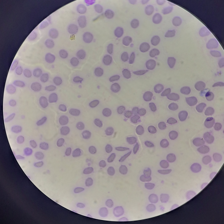

  -> backbone: resnet50 ... saved: 1_gradcam_resnet50.png
  -> backbone: efficientnetb0 ... saved: 1_gradcam_efficientnetb0.png
  -> backbone: mobilenetv2 ... saved: 1_gradcam_mobilenetv2.png

[2/4] Processing image: 16.jpg
 Original (preview):


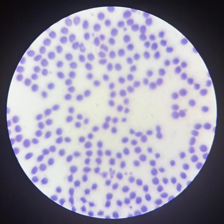

  -> backbone: resnet50 ... saved: 16_gradcam_resnet50.png
  -> backbone: efficientnetb0 ... saved: 16_gradcam_efficientnetb0.png
  -> backbone: mobilenetv2 ... saved: 16_gradcam_mobilenetv2.png

[3/4] Processing image: 17.jpg
 Original (preview):


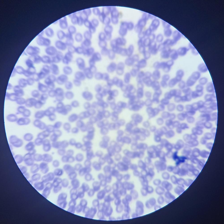

  -> backbone: resnet50 ... saved: 17_gradcam_resnet50.png
  -> backbone: efficientnetb0 ... saved: 17_gradcam_efficientnetb0.png
  -> backbone: mobilenetv2 ... saved: 17_gradcam_mobilenetv2.png

[4/4] Processing image: 2.jpg
 Original (preview):


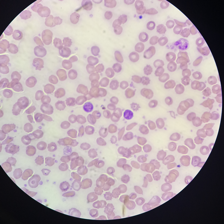

  -> backbone: resnet50 ... saved: 2_gradcam_resnet50.png
  -> backbone: efficientnetb0 ... saved: 2_gradcam_efficientnetb0.png
  -> backbone: mobilenetv2 ... saved: 2_gradcam_mobilenetv2.png

Batch complete. Overlays saved to: /kaggle/working/xai_outputs

Image: /kaggle/input/scd-for-fyp/1.jpg
   resnet50 -> /kaggle/working/xai_outputs/1_gradcam_resnet50.png
   efficientnetb0 -> /kaggle/working/xai_outputs/1_gradcam_efficientnetb0.png
   mobilenetv2 -> /kaggle/working/xai_outputs/1_gradcam_mobilenetv2.png

Image: /kaggle/input/scd-for-fyp/16.jpg
   resnet50 -> /kaggle/working/xai_outputs/16_gradcam_resnet50.png
   efficientnetb0 -> /kaggle/working/xai_outputs/16_gradcam_efficientnetb0.png
   mobilenetv2 -> /kaggle/working/xai_outputs/16_gradcam_mobilenetv2.png

Image: /kaggle/input/scd-for-fyp/17.jpg
   resnet50 -> /kaggle/working/xai_outputs/17_gradcam_resnet50.png
   efficientnetb0 -> /kaggle/working/xai_outputs/17_gradcam_efficientnetb0.png
   mobilenetv2 -> /kaggle/working/xai_out

In [24]:
import numpy as np, cv2, tensorflow as tf
from pathlib import Path
from PIL import Image
from IPython.display import display
from tensorflow.keras import applications, Model
from tensorflow.keras.layers import GlobalAveragePooling2D
import time

# config
PATHS_INPUT = """
/kaggle/input/scd-for-fyp/1.jpg
/kaggle/input/scd-for-fyp/16.jpg
/kaggle/input/scd-for-fyp/17.jpg
/kaggle/input/scd-for-fyp/2.jpg
""".strip()

OUT_DIR = Path("/kaggle/working/xai_outputs"); OUT_DIR.mkdir(parents=True, exist_ok=True)
BACKBONES = ["resnet50","efficientnetb0","mobilenetv2"]
IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)
DISPLAY_OUTPUTS = False   # set True to display overlays inline (may be noisy for many images)

# helpers
def parse_paths_input(s):
    s = str(s).strip()
    if not s:
        return []
    lines = [ln.strip() for ln in s.splitlines() if ln.strip()]
    return [str(Path(p).resolve()) for p in lines]

def preprocess_img(path, img_size=IMG_SIZE):
    x = tf.io.read_file(str(path))
    try:
        x = tf.io.decode_jpeg(x, channels=3)
    except Exception:
        x = tf.io.decode_image(x, channels=3, expand_animations=False)
    x = tf.image.convert_image_dtype(x, tf.float32)         # [0,1]
    x = tf.image.resize(x, [img_size, img_size])
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x.numpy()

def build_model_and_last_conv(backbone_name, img_size=IMG_SIZE):
    b = backbone_name.lower()
    if b == "resnet50":
        base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(img_size,img_size,3))
        last_conv = "conv5_block3_out"
    elif b == "efficientnetb0":
        base = applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_size,img_size,3))
        # try to find a meaningful conv layer near the end
        last_conv = None
        for layer in reversed(base.layers):
            if 'conv' in layer.name:
                last_conv = layer.name
                break
    elif b == "mobilenetv2":
        base = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size,img_size,3))
        # try to find last conv-like layer
        last_conv = None
        for layer in reversed(base.layers):
            if 'Conv_1' in layer.name or 'conv' in layer.name:
                last_conv = layer.name
                break
    else:
        raise ValueError("Unknown backbone: " + backbone_name)
    gap = GlobalAveragePooling2D()(base.output)
    head = tf.keras.layers.Dense(1, activation='sigmoid')(gap)
    model = Model(inputs=base.input, outputs=head)
    return model, last_conv

def compute_gradcam(model, conv_layer, image_tensor):
    img = np.expand_dims(image_tensor, axis=0).astype(np.float32)
    # build grad model: conv outputs + final prediction
    grad_model = Model([model.inputs], [model.get_layer(conv_layer).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    if grads is None:
        raise RuntimeError("Gradients None (check model/layers).")
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2)).numpy()
    conv_outs = conv_outputs[0].numpy()
    cam = np.zeros(conv_outs.shape[:2], dtype=np.float32)
    for i, w in enumerate(pooled_grads):
        cam += w * conv_outs[:, :, i]
    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / (cam.max() + 1e-9)
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    return cam

def overlay_and_save(orig_path, cam, out_path, alpha=0.45):
    orig = np.array(Image.open(orig_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))).astype(np.float32)/255.0
    heat = (255 * cam).astype(np.uint8)
    heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted((orig*255).astype(np.uint8), 1-alpha, heat, alpha, 0)
    Image.fromarray(overlay).save(out_path)
    return out_path

# batch runner
def batch_gradcam(paths, backbones=BACKBONES, display_outputs=DISPLAY_OUTPUTS):
    saved = []
    for i, p in enumerate(paths):
        pth = Path(p)
        if not pth.exists():
            print(f"[skip] missing: {p}")
            continue
        print(f"\n[{i+1}/{len(paths)}] Processing image: {pth.name}")
        # show original (small)
        try:
            print(" Original (preview):"); display(Image.open(pth).resize((IMG_SIZE, IMG_SIZE)))
        except Exception:
            pass
        # preprocess once
        try:
            pre = preprocess_img(pth)
        except Exception as e:
            print("  [error] preprocess failed:", e)
            continue

        per_image_generated = {}
        for b in backbones:
            print(f"  -> backbone: {b} ...", end=" ")
            try:
                model, last_conv_name = build_model_and_last_conv(b)
                # try to determine conv_layer
                if last_conv_name is None:
                    conv_layer = next((l.name for l in reversed(model.layers) if len(getattr(l, "output_shape", []))==4), None)
                    if conv_layer is None:
                        raise RuntimeError("No conv layer found")
                else:
                    conv_layer = last_conv_name
                cam = compute_gradcam(model, conv_layer, pre)
                outp = OUT_DIR / f"{pth.stem}_gradcam_{b}.png"
                overlay_and_save(pth, cam, str(outp))
                per_image_generated[b] = str(outp)
                print("saved:", outp.name)
            except Exception as e:
                per_image_generated[b] = None
                print("failed:", e)
            finally:
                # clear TF to free memory before next backbone
                try:
                    tf.keras.backend.clear_session()
                except Exception:
                    pass
        saved.append({"image": str(pth), "overlays": per_image_generated})
        # optionally display produced overlays immediately
        if display_outputs:
            for b, fp in per_image_generated.items():
                if fp:
                    print("   Overlay:", b)
                    try:
                        display(Image.open(fp))
                    except Exception:
                        pass
        # small pause to be polite to the runtime
        time.sleep(0.2)
    # summary
    print("\nBatch complete. Overlays saved to:", OUT_DIR)
    return saved

# run 
paths = parse_paths_input(PATHS_INPUT)
if not paths:
    raise RuntimeError("No image paths provided in PATHS_INPUT.")
results = batch_gradcam(paths, backbones=BACKBONES, display_outputs=DISPLAY_OUTPUTS)

# Print short summary of saved files
for r in results:
    print("\nImage:", r["image"])
    for b, fp in r["overlays"].items():
        print("  ", b, "->", ("MISSING" if fp is None else fp))


**SHAP**

Loaded model: /kaggle/working/ml_models/xgb_concat.joblib
Train concat shape: (312, 384)
Using TreeExplainer


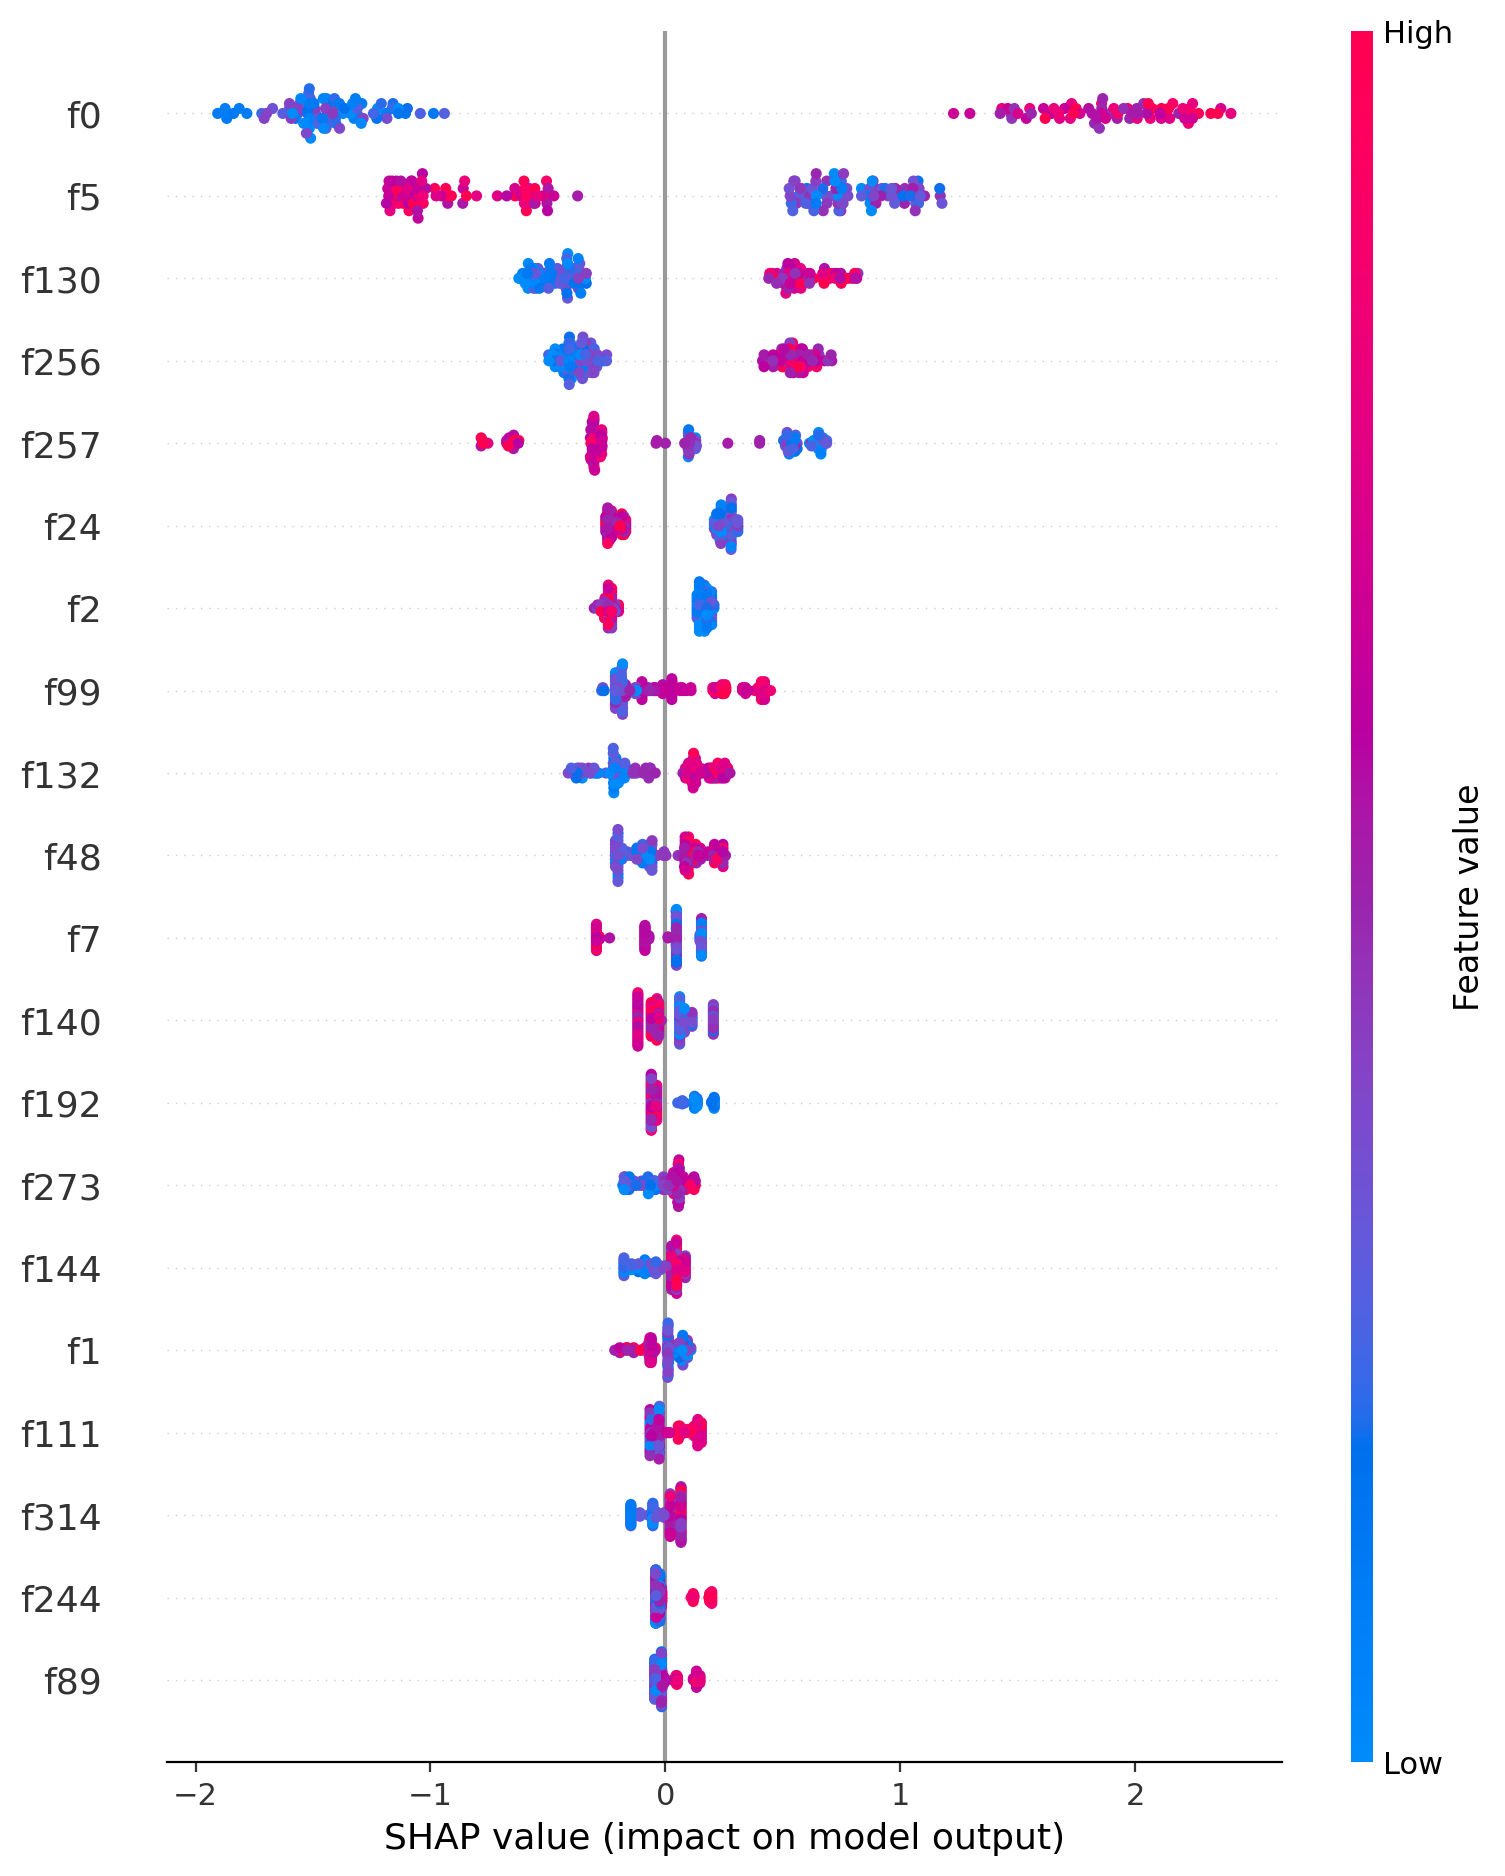

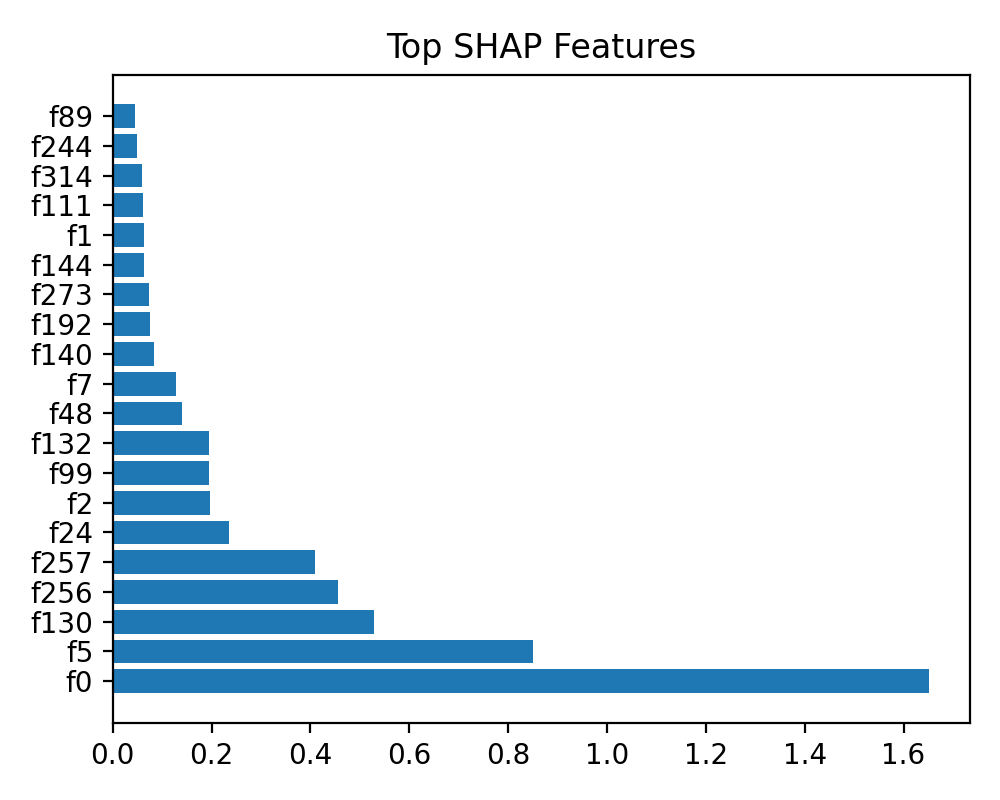

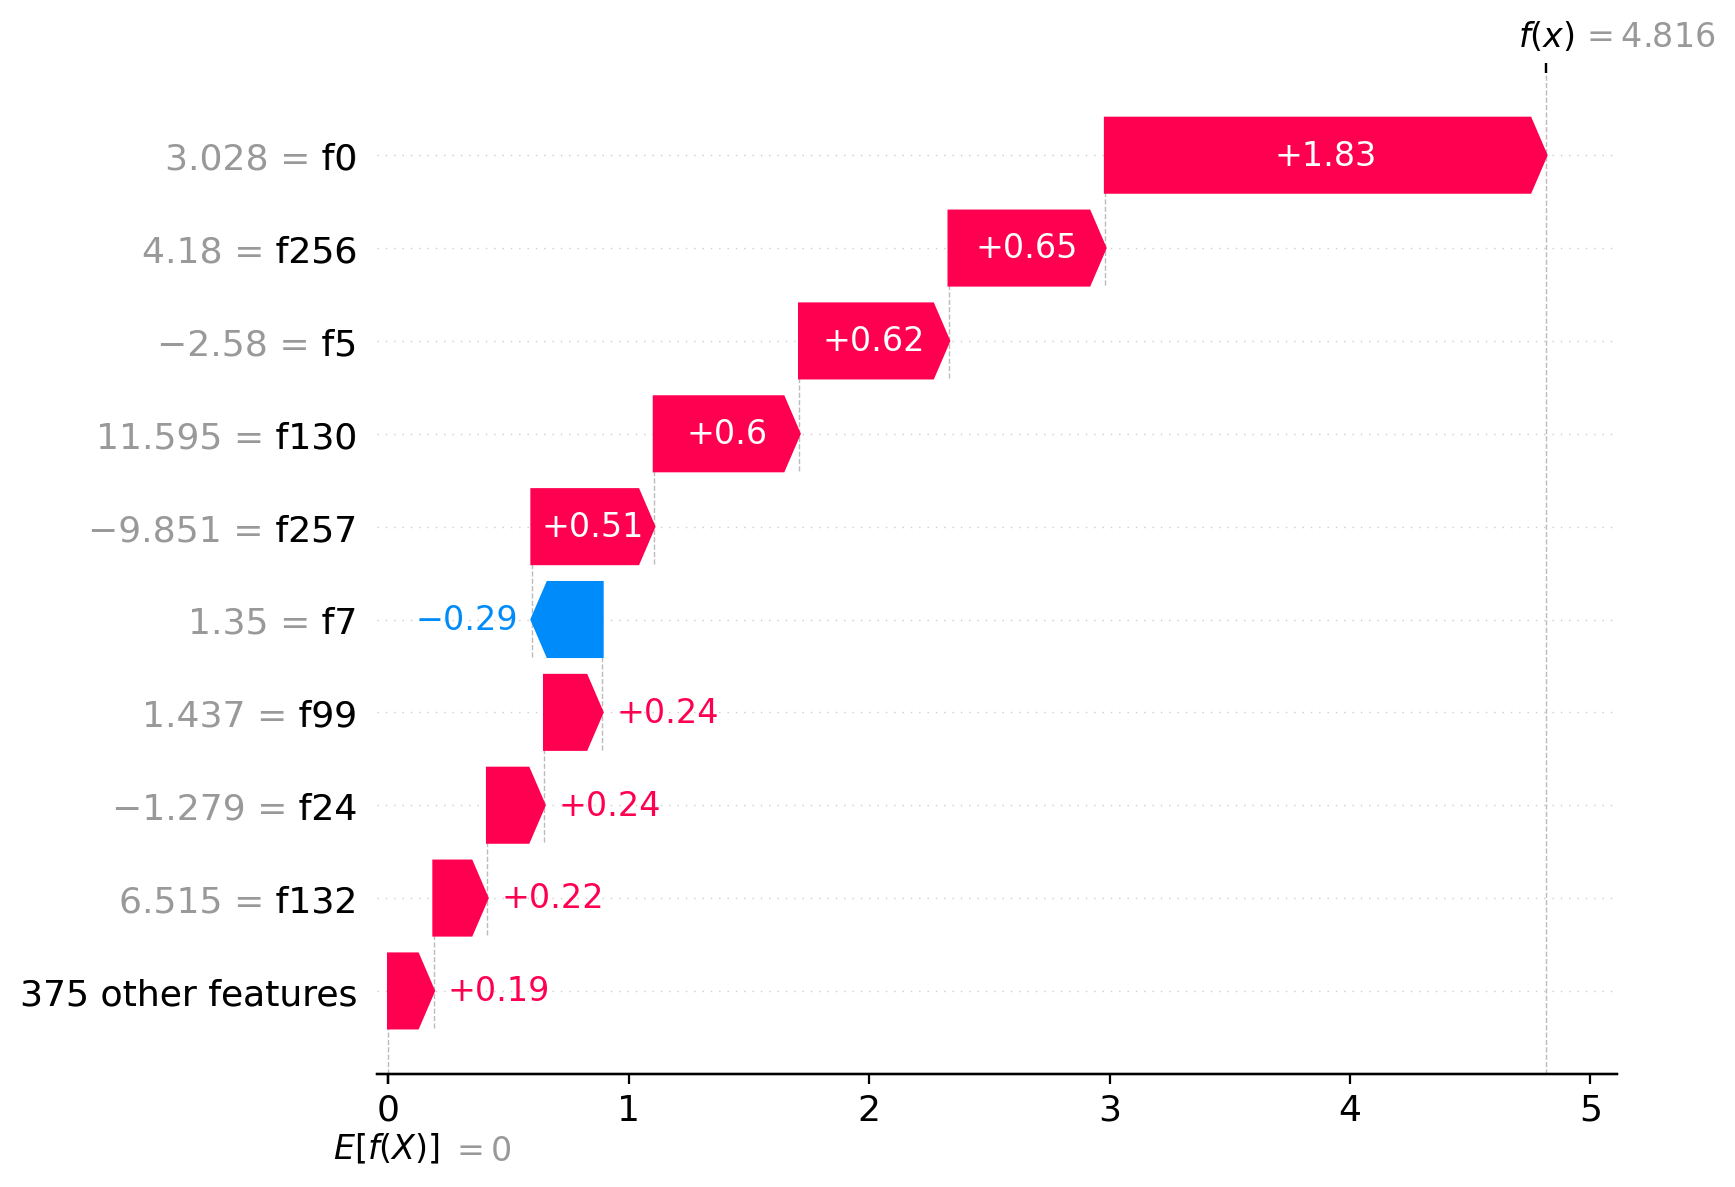


All SHAP small-size plots saved to: /kaggle/working/xai_shap_outputs


In [25]:
MODEL_PATH = "/kaggle/working/ml_models/xgb_concat.joblib"
TRAIN_CONCAT_PATH = "/kaggle/working/embeddings_multi/train_concat_resnet50_efficientnetb0_mobilenetv2.npz"
INSTANCE_INDEX = 0
X_INSTANCE = None
OUT_DIR = "/kaggle/working/xai_shap_outputs"

# Backend setup 
import os, joblib, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

OUT = Path(OUT_DIR); OUT.mkdir(parents=True, exist_ok=True)

# Install shap if needed
try:
    import shap
except:
    print("Installing shap…")
    !pip install -q shap
    import shap

from IPython.display import display, HTML, Image as IPyImage

import matplotlib
matplotlib.use("Agg")

MODEL_PATH = Path(MODEL_PATH)
TRAIN_CONCAT_PATH = Path(TRAIN_CONCAT_PATH)

# Load model 
model = joblib.load(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

# Load train concat
if X_INSTANCE is None:
    data = np.load(TRAIN_CONCAT_PATH)
    Xtrain = data["embeddings"]
    print("Train concat shape:", Xtrain.shape)

    bg_idx = np.random.RandomState(42).choice(len(Xtrain), size=min(150, len(Xtrain)), replace=False)
    background = Xtrain[bg_idx]

    X_instance = Xtrain[INSTANCE_INDEX:INSTANCE_INDEX+1]
else:
    X_instance = np.array(X_INSTANCE).reshape(1, -1)
    background = None

feature_names = [f"f{i}" for i in range(X_instance.shape[1])]

# SHAP explainer 
try:
    explainer = shap.TreeExplainer(model, data=background)
    expected_value = explainer.expected_value
    shap_vals = explainer.shap_values(X_instance)
    use_tree = True
    print("Using TreeExplainer")
except:
    explainer = shap.KernelExplainer(lambda z: model.predict_proba(z)[:,1], background)
    shap_vals = explainer.shap_values(X_instance, nsamples=100)
    expected_value = None
    use_tree = False
    print("Using KernelExplainer")

if isinstance(shap_vals, list) and len(shap_vals) == 2:
    shap_for_pos = np.array(shap_vals[1])
else:
    shap_for_pos = np.array(shap_vals)

# 1) SUMMARY PLOT (smaller)
try:
    plt.figure(figsize=(6,4))   # <- RESIZED HERE
    sample_idx = np.random.RandomState(0).choice(len(background), size=min(150, len(background)), replace=False)
    bg_sample = background[sample_idx]

    sv_bg = explainer.shap_values(bg_sample)
    if isinstance(sv_bg, list):
        sv_bg = sv_bg[1]

    shap.summary_plot(sv_bg, bg_sample, feature_names=feature_names, show=False)
    fp = OUT / "summary_small.png"
    plt.savefig(fp, dpi=200, bbox_inches="tight")
    plt.close()

    display(HTML("<h4>SHAP summary plot</h4>"))
    display(IPyImage(filename=str(fp), width=500))   # <- RESIZED
except Exception as e:
    print("Summary plot error:", e)

# 2) BAR PLOT (smaller)
try:
    arr = np.abs(sv_bg).mean(axis=0)
    top_idx = np.argsort(arr)[::-1][:20]

    plt.figure(figsize=(5,4))  # <- RESIZED
    plt.barh(range(len(top_idx))[::-1], arr[top_idx][::-1], align="center")
    plt.yticks(range(len(top_idx))[::-1], [feature_names[i] for i in top_idx][::-1])
    plt.title("Top SHAP Features")
    bp = OUT / "bar_small.png"
    plt.tight_layout()
    plt.savefig(bp, dpi=200)
    plt.close()

    display(HTML("<h4>SHAP bar plot</h4>"))
    display(IPyImage(filename=str(bp), width=500))   # <- RESIZED
except Exception as e:
    print("Bar plot error:", e)

# 3) WATERFALL PLOT (smaller)
try:
    base_val = expected_value[1] if (use_tree and isinstance(expected_value, (list, np.ndarray))) else 0

    expl = shap.Explanation(values=shap_for_pos[0],
                            base_values=base_val,
                            data=X_instance[0],
                            feature_names=feature_names)

    plt.figure(figsize=(6,4))   # <- RESIZED
    shap.plots.waterfall(expl, show=False)
    wf = OUT / "waterfall_small.png"
    plt.savefig(wf, dpi=200, bbox_inches="tight")
    plt.close()

    display(HTML("<h4>SHAP waterfall plot</h4>"))
    display(IPyImage(filename=str(wf), width=500))   # <- RESIZED
except Exception as e:
    print("Waterfall error:", e)

# 4) FORCE PLOT (interactive)
try:
    if use_tree:
        ev = expected_value[1] if isinstance(expected_value, (list,np.ndarray)) else expected_value
        vals = shap_for_pos[0]
        force = shap.force_plot(ev, vals, feature_names=feature_names, matplotlib=False)

        html_path = OUT / "force_small.html"
        shap.save_html(str(html_path), force)

        display(HTML("<h4>SHAP force plot (interactive)</h4>"))
        display(HTML(open(html_path).read()))   # <- INLINE HTML DISPLAY
    else:
        print("KernelExplainer does not support force plot well.")
except Exception as e:
    print("Force plot error:", e)

print("\nAll SHAP small-size plots saved to:", OUT)


In [26]:
# Textual summary & CSV/JSON saver

import json, time, pandas as pd
from pathlib import Path

def textual_summary_and_save(probs_dict, student_prob=None, meta_prob=None,
                             threshold=0.5, out_dir="/kaggle/working/xai_outputs",
                             image_path=None):
    outp = Path(out_dir); outp.mkdir(parents=True, exist_ok=True)

    print("\nModel probabilities (for POSITIVE class):")
    for k in sorted(probs_dict.keys()):
        v = probs_dict[k]
        if v is None:
            print(f"  {k:12s}:  N/A")
        else:
            print(f"  {k:12s}:  {v*100:6.2f}%")
    if student_prob is not None:
        print(f"  {'student':12s}:  {student_prob*100:6.2f}%")
    if meta_prob is not None:
        print(f"  {'stacking_meta':12s}:  {meta_prob*100:6.2f}%")

    # select final prob/source
    final_prob = None; final_source = "none"
    if meta_prob is not None:
        final_prob = float(meta_prob); final_source = "stacking_meta"
    elif (student_prob is not None) and ("voting" in probs_dict and probs_dict["voting"] is not None):
        final_prob = 0.6 * float(student_prob) + 0.4 * float(probs_dict["voting"]); final_source = "weighted_student_voting"
    elif student_prob is not None:
        final_prob = float(student_prob); final_source = "student_only"
    elif "voting" in probs_dict and probs_dict["voting"] is not None:
        final_prob = float(probs_dict["voting"]); final_source = "voting_only"

    if final_prob is None:
        label_text = "Unknown"; pred = None
        print("\nFinal prob : N/A  -> Predicted: Unknown")
    else:
        label_text = "Positive" if final_prob >= threshold else "Negative"
        pred = 1 if label_text == "Positive" else 0
        print(f"\nFinal prob : {final_prob*100:6.2f}% (source: {final_source})")
        print(f"Threshold  : {threshold*100:.0f}%")
        print(f"Predicted  : {label_text}  ({pred})")

    # Save
    row = {"image": image_path if image_path else None, "final_prob": final_prob,
           "pred_label": pred, "label_text": label_text, "final_source": final_source, "timestamp": int(time.time())}
    for k,v in probs_dict.items(): row[f"prob_{k}"] = v
    row["prob_student"] = student_prob
    row["prob_meta"] = meta_prob

    csvp = outp / f"summary_{Path(image_path).stem if image_path else 'unnamed'}_{int(time.time())}.csv"
    pd.DataFrame([row]).to_csv(csvp, index=False)
    jpath = outp / f"summary_{Path(image_path).stem if image_path else 'unnamed'}_{int(time.time())}.json"
    with open(jpath, "w") as f: json.dump(row, f, indent=2)

    print("Saved summary CSV:", csvp)
    return row


**STAGE 9 : (Final evaluation + reporting + export)**

In [27]:
import os, json, joblib, zipfile, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve, auc)

warnings.filterwarnings("ignore")

# CONFIG (adjust if needed)
WORK = Path("/kaggle/working")
EMB_DIR = WORK / "embeddings_multi"
MODELS_DIR = WORK / "ml_models"
HYBRID_DIR = WORK / "hybrid_models"
DISTILL_DIR = WORK / "distillation"
OUT_DIR = WORK / "final_stage_outputs"; OUT_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE_ORDER = ["resnet50","efficientnetb0","mobilenetv2"]
CONCAT_TAG = "_".join(BACKBONE_ORDER)
TEST_CONCAT = EMB_DIR / f"test_concat_{CONCAT_TAG}.npz"

MODEL_FILES = {
    "svm": MODELS_DIR / "svm_concat.joblib",
    "knn": MODELS_DIR / "knn_concat.joblib",
    "xgb": MODELS_DIR / "xgb_concat.joblib",
    "voting": MODELS_DIR / "voting_concat.joblib",
    "stacking_meta": HYBRID_DIR / "stacking_meta_logreg.joblib",
    "scaler_concat": MODELS_DIR / "scaler_concat.joblib"
}
STUDENT_CAND = sorted(list(DISTILL_DIR.glob("student_final_*.h5")) + list(DISTILL_DIR.glob("student_best_*.h5")))
STUDENT_FILE = STUDENT_CAND[-1] if STUDENT_CAND else None

print("Using files:")
for k,v in MODEL_FILES.items():
    print(f" - {k}: exists={v.exists()}  path={v}")
print("Student model:", STUDENT_FILE)

# Load test concat embeddings 
if not TEST_CONCAT.exists():
    raise FileNotFoundError(f"Missing test concat embeddings: {TEST_CONCAT}. Re-run Stage 3 to produce it.")

d = np.load(TEST_CONCAT)
X_test = d["embeddings"].astype(np.float32)
y_test = d["labels"].astype(int).ravel()
print("Loaded test embeddings shape:", X_test.shape, "labels:", y_test.shape)

# Helperer 
def safe_load_joblib(p: Path):
    try:
        return joblib.load(p) if p.exists() else None
    except Exception as e:
        print("Failed to load", p, ":", e)
        return None

def safe_proba(model, X):
    """Return (scores, preds) where scores may be None if not available.
    scores should be shape (n,) or None; preds should be integer array if possible."""
    if model is None:
        return None, None
    try:
        proba = model.predict_proba(X)
        proba = np.asarray(proba)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            scores = proba[:,1]
        else:
            scores = proba.ravel()
    except Exception:
        try:
            df = model.decision_function(X)
            scores = 1.0/(1.0+np.exp(-np.asarray(df).ravel()))
        except Exception:
            scores = None
    try:
        preds = model.predict(X)
        preds = np.asarray(preds).astype(int).ravel()
    except Exception:
        preds = None
    return scores, preds

# Load artifacts
svm = safe_load_joblib(MODEL_FILES["svm"])
knn = safe_load_joblib(MODEL_FILES["knn"])
xgb = safe_load_joblib(MODEL_FILES["xgb"])
voting = safe_load_joblib(MODEL_FILES["voting"])
stacking_meta = safe_load_joblib(MODEL_FILES["stacking_meta"])
scaler_concat = safe_load_joblib(MODEL_FILES["scaler_concat"])

# load student (tf.keras) safely
student = None
if STUDENT_FILE is not None:
    try:
        import tensorflow as tf
        student = tf.keras.models.load_model(str(STUDENT_FILE), compile=False)
        print("Loaded student model from:", STUDENT_FILE)
    except Exception as e:
        print("Failed to load student model:", e)
        student = None

# scale test features if scaler exists (otherwise assume already preprocessed)
X_test_scaled = X_test
if scaler_concat is not None:
    try:
        X_test_scaled = scaler_concat.transform(X_test)
        print("Applied global scaler to test set.")
    except Exception as e:
        print("Global scaler.transform failed:", e)
        X_test_scaled = X_test

# Evaluate classical models
models_to_eval = {"svm": svm, "knn": knn, "xgb": xgb, "voting": voting}
eval_records = []

def eval_model_and_save(name, mdl, Xs, ytrue):
    rec = {"model": name, "n_samples": len(ytrue)}
    if mdl is None:
        rec.update({"accuracy":None,"precision":None,"recall":None,"f1":None,"auc":None})
        # still save an empty preds csv
        pd.DataFrame({"y_true": ytrue}).to_csv(OUT_DIR / f"{name}_preds.csv", index=False)
        return rec
    scores, preds = safe_proba(mdl, Xs)
    # If preds missing, try to compute from scores threshold 0.5
    if preds is None and scores is not None:
        try:
            preds = (np.asarray(scores) >= 0.5).astype(int)
        except Exception:
            preds = None
    if preds is None:
        rec.update({"accuracy":None,"precision":None,"recall":None,"f1":None,"auc":None})
        return rec
    acc = accuracy_score(ytrue, preds)
    prec = precision_score(ytrue, preds, zero_division=0)
    recs = recall_score(ytrue, preds, zero_division=0)
    f1 = f1_score(ytrue, preds, zero_division=0)
    try:
        aucv = roc_auc_score(ytrue, scores) if (scores is not None and len(np.unique(ytrue))>1) else None
    except Exception:
        aucv = None
    rec.update({"accuracy":acc,"precision":prec,"recall":recs,"f1":f1,"auc":aucv})
    # save predictions table
    preds_df = pd.DataFrame({"y_true": ytrue, "y_pred": preds})
    if scores is not None:
        preds_df["y_score"] = scores
    preds_df.to_csv(OUT_DIR / f"{name}_preds.csv", index=False)
    print(f"Saved {name} preds to {OUT_DIR / f'{name}_preds.csv'}")
    return rec

for name, mdl in models_to_eval.items():
    rec = eval_model_and_save(name, mdl, X_test_scaled, y_test)
    eval_records.append(rec)

# Evaluate student
if student is not None:
    try:
        # student expected to accept same scaled features used by classical models
        s_scores = student.predict(X_test_scaled, batch_size=32).ravel()
        s_preds = (s_scores >= 0.5).astype(int)
        rec = {
            "model":"student",
            "n_samples": len(y_test),
            "accuracy": accuracy_score(y_test, s_preds),
            "precision": precision_score(y_test, s_preds, zero_division=0),
            "recall": recall_score(y_test, s_preds, zero_division=0),
            "f1": f1_score(y_test, s_preds, zero_division=0),
            "auc": (roc_auc_score(y_test, s_scores) if len(np.unique(y_test))>1 else None)
        }
        pd.DataFrame({"y_true": y_test, "y_score": s_scores, "y_pred": s_preds}).to_csv(OUT_DIR / "student_preds.csv", index=False)
        print("Saved student_preds.csv")
    except Exception as e:
        print("Student eval failed:", e)
        rec = {"model":"student","n_samples":len(y_test),"accuracy":None,"precision":None,"recall":None,"f1":None,"auc":None}
    eval_records.append(rec)
else:
    eval_records.append({"model":"student","n_samples":len(y_test),"accuracy":None,"precision":None,"recall":None,"f1":None,"auc":None})

# Evaluate stacking meta (reconstruct using same sorted order) 
if stacking_meta is not None:
    try:
        # determine classical names in sorted order used earlier
        classical_names = sorted([k for k in models_to_eval.keys()])
        # collect probs for each classical model
        meta_feats = []
        any_ok = False
        for nm in classical_names:
            mdl = models_to_eval.get(nm)
            if mdl is None:
                meta_feats.append(np.zeros(len(y_test)))
                continue
            scores, _ = safe_proba(mdl, X_test_scaled)
            if scores is None:
                # fallback to zeros
                scores = np.zeros(len(y_test))
            else:
                any_ok = True
            meta_feats.append(np.asarray(scores))
        # student scores
        if student is not None:
            try:
                s_scores = student.predict(X_test_scaled, batch_size=32).ravel()
                meta_feats.append(s_scores)
                any_ok = True
            except Exception:
                meta_feats.append(np.zeros(len(y_test)))
        else:
            meta_feats.append(np.zeros(len(y_test)))
        if any_ok:
            meta_X = np.vstack(meta_feats).T
            # predict
            try:
                meta_proba = stacking_meta.predict_proba(meta_X)[:,1]
                meta_pred = (meta_proba >= 0.5).astype(int)
                rec = {
                    "model":"stacking_meta",
                    "n_samples": len(y_test),
                    "accuracy": accuracy_score(y_test, meta_pred),
                    "precision": precision_score(y_test, meta_pred, zero_division=0),
                    "recall": recall_score(y_test, meta_pred, zero_division=0),
                    "f1": f1_score(y_test, meta_pred, zero_division=0),
                    "auc": (roc_auc_score(y_test, meta_proba) if len(np.unique(y_test))>1 else None)
                }
                # save preds
                pd.DataFrame({"y_true": y_test, "y_score": meta_proba, "y_pred": meta_pred}).to_csv(OUT_DIR / "stacking_meta_preds.csv", index=False)
            except Exception as e:
                print("Stacking meta prediction failed:", e)
                rec = {"model":"stacking_meta","n_samples":len(y_test),"accuracy":None,"precision":None,"recall":None,"f1":None,"auc":None}
        else:
            rec = {"model":"stacking_meta","n_samples":len(y_test),"accuracy":None,"precision":None,"recall":None,"f1":None,"auc":None}
    except Exception as e:
        print("Stacking meta eval failed:", e)
        rec = {"model":"stacking_meta","n_samples":len(y_test),"accuracy":None,"precision":None,"recall":None,"f1":None,"auc":None}
else:
    rec = {"model":"stacking_meta","n_samples":len(y_test),"accuracy":None,"precision":None,"recall":None,"f1":None,"auc":None}
eval_records.append(rec)

# Save overall summary 
df_res = pd.DataFrame(eval_records)
df_res.to_csv(OUT_DIR / "evaluation_summary.csv", index=False)
print("Saved evaluation summary to:", OUT_DIR / "evaluation_summary.csv")
print(df_res)

# Save detailed reports, CM and ROC plots
def plot_confusion(cm, classes, title, outpath):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(int(cm[i, j]), fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(outpath); plt.close()

def plot_roc(y_true, y_score, outpath, label):
    if y_score is None:
        return
    try:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.4f})')
        plt.plot([0,1],[0,1],'k--', alpha=0.4)
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC - {label}')
        plt.legend(loc='lower right')
        plt.grid(alpha=0.2)
        plt.savefig(outpath); plt.close()
    except Exception as e:
        print("Failed to plot ROC for", label, ":", e)

# iterate saved preds CSVs for each model to create reports
model_names_for_reports = ["svm","knn","xgb","voting","student","stacking_meta"]
for name in model_names_for_reports:
    pfile = OUT_DIR / f"{name}_preds.csv"
    if not pfile.exists():
        continue
    pdat = pd.read_csv(pfile)
    if "y_pred" not in pdat.columns:
        continue
    ypred = pdat["y_pred"].values
    yscore = pdat["y_score"].values if "y_score" in pdat.columns else None
    # classification report
    crep = classification_report(y_test, ypred, digits=4, output_dict=True)
    crep_path = OUT_DIR / f"{name}_classification_report.json"
    with open(crep_path, "w") as fh:
        json.dump(crep, fh, indent=2)
    # confusion and ROC
    cm = confusion_matrix(y_test, ypred)
    cm_path = OUT_DIR / f"{name}_confusion.png"
    plot_confusion(cm, classes=[0,1], title=f"Confusion - {name}", outpath=cm_path)
    roc_path = OUT_DIR / f"{name}_roc.png"
    plot_roc(y_test, yscore, roc_path, label=name)
    print("Saved reports for", name)

print("Saved detailed reports to:", OUT_DIR)

# Package artifacts into a zip for download 
zip_path = WORK / f"models_and_reports_{int(time.time())}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    # add models & scalers (only certain suffixes)
    for base_dir in [MODELS_DIR, HYBRID_DIR, DISTILL_DIR]:
        if base_dir.exists():
            for f in base_dir.rglob("*"):
                if f.is_file() and f.suffix.lower() in (".joblib", ".h5", ".json", ".csv", ".png"):
                    try:
                        arcname = f"{base_dir.name}/{f.name}"
                        z.write(f, arcname=arcname)
                    except Exception:
                        pass
    # add reports
    for f in OUT_DIR.rglob("*"):
        if f.is_file():
            try:
                z.write(f, arcname=f"reports/{f.name}")
            except Exception:
                pass

print("Packaged artifacts to:", zip_path)

# Optional: lightweight Streamlit scaffold file 
streamlit_file = WORK / "quick_demo_streamlit.py"
st_content = f'''
# Simple Streamlit demo scaffold (edit to integrate pipeline)
import streamlit as st
st.title("Sickle Cell Detection - Quick Demo")
st.write("This is a scaffold. Integrate feature extraction + transforms from the notebook.")
'''
try:
    streamlit_file.write_text(st_content)
    print("Wrote Streamlit scaffold to:", streamlit_file)
except Exception as e:
    print("Failed to write Streamlit file:", e)

print("\nSTAGE 9 complete. Check outputs in:", OUT_DIR)
print("Download archive:", zip_path)


Using files:
 - svm: exists=True  path=/kaggle/working/ml_models/svm_concat.joblib
 - knn: exists=True  path=/kaggle/working/ml_models/knn_concat.joblib
 - xgb: exists=True  path=/kaggle/working/ml_models/xgb_concat.joblib
 - voting: exists=True  path=/kaggle/working/ml_models/voting_concat.joblib
 - stacking_meta: exists=True  path=/kaggle/working/hybrid_models/stacking_meta_logreg.joblib
 - scaler_concat: exists=True  path=/kaggle/working/ml_models/scaler_concat.joblib
Student model: /kaggle/working/distillation/student_final_1764538938.h5
Loaded test embeddings shape: (171, 384) labels: (171,)
Loaded student model from: /kaggle/working/distillation/student_final_1764538938.h5
Applied global scaler to test set.
Saved svm preds to /kaggle/working/final_stage_outputs/svm_preds.csv
Saved knn preds to /kaggle/working/final_stage_outputs/knn_preds.csv
Saved xgb preds to /kaggle/working/final_stage_outputs/xgb_preds.csv
Saved voting preds to /kaggle/working/final_stage_outputs/voting_preds

In [28]:
# ROC overlay (Stage 9) 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_curve, auc

OUT_DIR = Path("/kaggle/working/final_stage_outputs")
models = ["svm","knn","xgb","voting","student","stacking_meta"]
plt.figure(figsize=(7,6))
any_plotted = False
for m in models:
    pfile = OUT_DIR / f"{m}_preds.csv"
    if not pfile.exists(): continue
    df = pd.read_csv(pfile)
    if "y_score" not in df.columns: continue
    fpr, tpr, _ = roc_curve(df.y_true.values, df.y_score.values)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{m} (AUC={roc_auc:.3f})")
    any_plotted = True

if any_plotted:
    plt.plot([0,1],[0,1],"k--", alpha=0.4)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Overlay")
    plt.legend(loc="lower right"); plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    plt.savefig(OUT_DIR/"roc_overlay.png", dpi=160, bbox_inches="tight")
    print("Saved ROC overlay to", OUT_DIR/"roc_overlay.png")
else:
    print("No models with y_score found in", OUT_DIR)


Saved ROC overlay to /kaggle/working/final_stage_outputs/roc_overlay.png


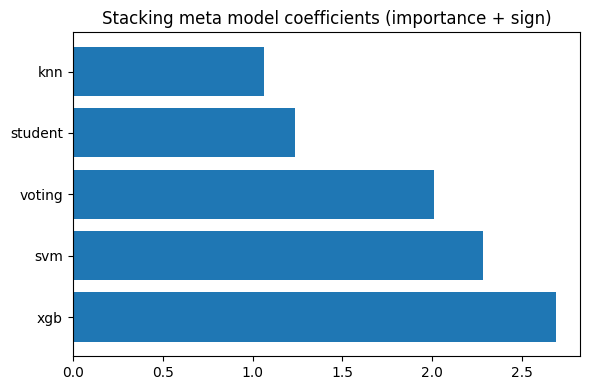

Saved stacking_meta_coeffs.png to /kaggle/working/final_stage_outputs


In [21]:
# Meta-model feature importance (Stage 9)
import joblib, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

HYBRID_DIR = Path("/kaggle/working/hybrid_models")
meta_path = HYBRID_DIR / "stacking_meta_logreg.joblib"
if not meta_path.exists():
    raise FileNotFoundError("stacking_meta_logreg.joblib not found")

meta = joblib.load(meta_path)
coef = getattr(meta, "coef_", None)
if coef is None:
    print("Meta model has no coef_. If it's not linear, use permutation importance instead.")
else:
    coef = coef.ravel()
    # feature names must match training order: classical names sorted + 'student'
    classical_names = sorted(["svm","knn","xgb","voting"])
    feat_names = classical_names + ["student"]
    assert len(feat_names) == len(coef)
    inds = np.argsort(np.abs(coef))[::-1]
    plt.figure(figsize=(6,4))
    plt.barh([feat_names[i] for i in inds], coef[inds])
    plt.title("Stacking meta model coefficients (importance + sign)")
    plt.tight_layout()
    out = Path("/kaggle/working/final_stage_outputs"); out.mkdir(exist_ok=True)
    plt.savefig(out/"stacking_meta_coeffs.png", dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved stacking_meta_coeffs.png to", out)


In [29]:
# Robust radar chart for model comparison (Stage 9)
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

WORK = Path("/kaggle/working")
OUT_DIR = WORK / "final_stage_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Try to find a summary CSV (common names)
candidate_summary_paths = [
    OUT_DIR / "evaluation_summary.csv",
    OUT_DIR / "models_summary_test.csv",
    WORK / "evaluation_summary.csv",
]

summary_path = None
for p in candidate_summary_paths:
    if p.exists():
        summary_path = p
        break

def safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

def compute_metrics_from_preds(preds_csv_paths):
    """Given a list of *_preds.csv paths, compute the metrics and return a DataFrame"""
    rows = []
    for p in preds_csv_paths:
        try:
            df = pd.read_csv(p)
            # we expect columns 'y_true' and either 'y_pred' or 'y_score'
            if "y_true" not in df.columns:
                print("Skipping (no y_true):", p)
                continue
            y_true = df["y_true"].values
            if "y_pred" in df.columns:
                y_pred = df["y_pred"].values
            elif "y_score" in df.columns:
                y_pred = (df["y_score"].values >= 0.5).astype(int)
            else:
                print("Skipping (no y_pred/y_score):", p)
                continue
            # try to get scores for AUC if present
            y_score = df["y_score"].values if "y_score" in df.columns else None

            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            try:
                aucv = roc_auc_score(y_true, y_score) if (y_score is not None and len(np.unique(y_true))>1) else None
            except Exception:
                aucv = None

            rows.append({
                "model": p.stem.replace("_preds",""),
                "accuracy": acc,
                "precision": prec,
                "recall": rec,
                "f1": f1,
                "auc": aucv
            })
        except Exception as e:
            print("Failed to compute metrics from", p, ":", e)
    return pd.DataFrame(rows)

# If summary csv exists load it, else try to assemble from *_preds.csv
if summary_path is not None:
    print("Loading summary from:", summary_path)
    df = pd.read_csv(summary_path)
    # Try to ensure column names match expected; if different, try common alternatives
    # If df contains columns like 'val_accuracy'/'test_accuracy', prefer 'test' or last row
    if {"model","accuracy","precision","recall","f1","auc"}.issubset(set(df.columns)):
        df_metrics = df[["model","accuracy","precision","recall","f1","auc"]].copy()
    else:
        # try to find test metrics columns
        possible_suffixes = ["test_","val_",""]
        picked = None
        for suf in possible_suffixes:
            cols = [f"{suf}accuracy", f"{suf}precision", f"{suf}recall", f"{suf}f1", f"{suf}auc"]
            if all(c in df.columns for c in cols):
                picked = suf
                break
        if picked is not None:
            df_metrics = pd.DataFrame({
                "model": df["model"].values,
                "accuracy": df[f"{picked}accuracy"].values,
                "precision": df[f"{picked}precision"].values,
                "recall": df[f"{picked}recall"].values,
                "f1": df[f"{picked}f1"].values,
                "auc": df[f"{picked}auc"].values
            })
        else:
            # fallback: use what's available and coerce
            print("Summary file found but columns do not match expected format. Trying to use available columns.")
            # take numeric columns apart from model if present
            numeric_cols = [c for c in df.columns if c!="model"]
            use_cols = numeric_cols[:5]  # pick up to 5
            df_metrics = df.copy()
            # ensure at least model column present
            if "model" not in df_metrics.columns:
                df_metrics["model"] = df_metrics.index.astype(str)
            # fill missing metric names with zeros
            for col in ["accuracy","precision","recall","f1","auc"]:
                if col not in df_metrics.columns:
                    df_metrics[col] = None
            df_metrics = df_metrics[["model","accuracy","precision","recall","f1","auc"]].copy()
else:
    # find all *_preds.csv files
    all_preds = list(OUT_DIR.glob("*_preds.csv"))
    if len(all_preds) == 0:
        print("No summary CSV and no *_preds.csv files found in", OUT_DIR)
        # try other likely folder
        alt = list(WORK.glob("*_preds.csv"))
        all_preds = alt
    if len(all_preds) == 0:
        raise FileNotFoundError("Couldn't find evaluation_summary.csv or any *_preds.csv to compute metrics from.")
    print("Building metrics from preds CSV files:", [p.name for p in all_preds])
    df_metrics = compute_metrics_from_preds(all_preds)

# Inspect df_metrics
print("\nMetrics DataFrame (raw):")
print(df_metrics)

# Clean / normalize metrics: replace None/NaN with 0, ensure floats in [0,1]
for col in ["accuracy","precision","recall","f1","auc"]:
    if col not in df_metrics.columns:
        df_metrics[col] = 0.0
    df_metrics[col] = df_metrics[col].apply(lambda x: safe_float(x) if x is not None else None)
    df_metrics[col] = df_metrics[col].fillna(0.0).astype(float)
    # Clip to [0,1]
    df_metrics[col] = df_metrics[col].clip(0.0, 1.0)

# If AUC column was all zeros (because scores missing), try to compute auc from preds if available
if df_metrics["auc"].sum() == 0:
    # attempt to compute from preds csv individually
    recomputed = []
    for idx, row in df_metrics.iterrows():
        model_name = row["model"]
        preds_path = OUT_DIR / f"{model_name}_preds.csv"
        if preds_path.exists():
            try:
                d = pd.read_csv(preds_path)
                if "y_score" in d.columns and "y_true" in d.columns:
                    try:
                        aucv = roc_auc_score(d["y_true"].values, d["y_score"].values) if len(np.unique(d["y_true"]))>1 else 0.0
                        df_metrics.loc[idx,"auc"] = float(np.clip(aucv, 0.0, 1.0))
                    except Exception:
                        pass
            except Exception:
                pass

# If there are metric values >1 (accidentally percentages), scale them down if max>1
for col in ["accuracy","precision","recall","f1","auc"]:
    if df_metrics[col].max() > 1.01:
        print(f"Column {col} seems >1 (max {df_metrics[col].max():.2f}); scaling down by 100")
        df_metrics[col] = df_metrics[col] / 100.0
        df_metrics[col] = df_metrics[col].clip(0.0, 1.0)

print("\nMetrics DataFrame (cleaned, clipped to [0,1]):")
print(df_metrics)

# PLOT RADAR
def radar_compare(df_metrics, metrics=["accuracy","precision","recall","f1","auc"], out="/kaggle/working/radar_models.png"):
    labels = metrics
    num_vars = len(labels)

    # angles for plotting
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    # draw one axe per variable + add labels
    plt.xticks(angles[:-1], labels, color='grey', size=12)

    # draw ylabels
    ax.set_rlabel_position(30)
    ax.set_ylim(0, 1)

    # Plot each model
    for idx, row in df_metrics.iterrows():
        values = [row[m] for m in labels]
        # ensure numeric and in range
        values = [0.0 if v is None else float(v) for v in values]
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=row["model"])
        ax.fill(angles, values, alpha=0.15)

    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title("Model comparison (radar)", fontsize=16)
    plt.tight_layout()
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved:", out)

# call plot
outpath = "/kaggle/working/radar_models.png"
radar_compare(df_metrics, metrics=["accuracy","precision","recall","f1","auc"], out=outpath)


Loading summary from: /kaggle/working/final_stage_outputs/evaluation_summary.csv

Metrics DataFrame (raw):
           model  accuracy  precision    recall        f1       auc
0            svm  0.947368   0.960938  0.968504  0.964706  0.954724
1            knn  0.643275   0.971429  0.535433  0.690355  0.914370
2            xgb  0.982456   0.992063  0.984252  0.988142  0.993558
3         voting  0.964912   0.991870  0.960630  0.976000  0.992305
4        student  0.912281   0.951613  0.929134  0.940239  0.913923
5  stacking_meta  0.970760   0.976562  0.984252  0.980392  0.993916

Metrics DataFrame (cleaned, clipped to [0,1]):
           model  accuracy  precision    recall        f1       auc
0            svm  0.947368   0.960938  0.968504  0.964706  0.954724
1            knn  0.643275   0.971429  0.535433  0.690355  0.914370
2            xgb  0.982456   0.992063  0.984252  0.988142  0.993558
3         voting  0.964912   0.991870  0.960630  0.976000  0.992305
4        student  0.912281   